# Generation evaluation — distilled adapter vs one-shot baseline

Retrieval metrics are gone. Retrieval survives only as the thing that fetches context; nothing
about it is scored here. Everything measured in this notebook is a property of the **generator**.

## What is being compared

Both models are Gemma-3-4B, both read the **same retrieved chunks**, both decode greedily at
temperature 0. The only difference is how each one learned the KCC answer style:

| arm | how it knows the format |
|---|---|
| **`baseline_oneshot`** | base `gemma-3-4b-it` + **one worked example** in the prompt: a question, its context, and a model KCC-style answer |
| **`distilled`** | base + the trained LoRA adapter, same prompt **without** the example |
| `baseline_zeroshot` *(optional)* | base, no example, no adapter |

**Why one-shot is the right baseline.** A zero-shot base model against a distilled one mostly
measures output formatting — the base writes a polite paragraph, the reference is a 15-word
operational note, and BLEU punishes the paragraph. That gap is real but it is not what fine-tuning
was for. Giving the baseline one exemplar hands it the format for free, so what remains in the gap
is domain behaviour: does it name the right chemical, keep the right dose, stay in the retrieved
context. Turn on `INCLUDE_ZERO_SHOT` to see both, and the difference between the two baselines is
a clean estimate of how much of the distillation gain was only formatting.

**The exemplar is fixed, hand-written, and not drawn from the evaluation set.** A one-shot example
sampled from the eval questions would leak.

## What is measured

- **chrF++** — lead with this. Character n-grams survive Hindi morphology; `दवा`/`दवाई` score near
  zero on BLEU and high on chrF.
- **BLEU, ROUGE-1/2/L** — reported, quoted last. BLEU is the weakest signal on short Indic text.
- **Numeric fidelity** — share of the gold answer's numbers reproduced, and the rate of numbers in
  the answer that appear nowhere in the retrieved context. For agricultural advice a wrong dose is
  the failure that matters, and no n-gram metric can see it.
- **Grounding** (`context_recall`) — share of the answer's content words present in the chunks it
  was shown. Low grounding with high BLEU means the model is answering from memory, which for a
  distilled model evaluated on possibly-trained-on questions is precisely the thing to catch.
- **Script compliance and refusal rate** — a model that answers in the wrong script, or refuses,
  scores near zero on everything else; those cases need separating rather than averaging in.
- **Paired bootstrap CIs** on every difference. n=48; a gap whose interval crosses zero is a tie.

## 1. Packages

In [1]:
# !pip install -q gdown sacrebleu rank-bm25 qdrant-client sentence-transformers peft bitsandbytes accelerate --break-system-packages 2>/dev/null || pip install -q gdown sacrebleu rank-bm25 qdrant-client sentence-transformers peft bitsandbytes accelerate

import importlib
for _m in ("gdown", "sacrebleu", "qdrant_client", "sentence_transformers", "peft"):
    try:
        importlib.import_module(_m)
        print(f"   ok   {_m}")
    except ImportError as _e:
        print(f"   FAIL {_m}: {_e}")

   ok   gdown
   ok   sacrebleu
   ok   qdrant_client
   ok   sentence_transformers
   ok   peft


## 2. Configuration

`CONTEXT_MODE` decides what the generator reads:

- `"retrieved"` — the live RAG path. The honest end-to-end number.
- `"oracle"` — inject a chunk that actually contains the gold answer. This isolates the generator
  from retrieval: whatever the models score here is what they would score with a perfect retriever.
  Running both and comparing is the cleanest way to say how much of the answer quality is bounded
  by retrieval rather than by the model.

Run `"retrieved"` first. If both models score poorly there and well under `"oracle"`, the generator
is not your problem.

In [3]:
# ---- Drive sources ---------------------------------------------------------------------------
DRIVE_FOLDER   = "https://drive.google.com/drive/folders/1ZHUf7cljr3rR95i5O90dL1D73YrPR6co"
SNAPSHOT_FILE  = "https://drive.google.com/file/d/1FhTHMfyOzLGfOq6VLh_V6tnTNGe-ro1N/view?usp=drive_link"
MANIFEST_FILE  = "https://drive.google.com/file/d/1JnbcSbVzqcOEeZLU_-kuNb5uB6ZzTePL/view?usp=drive_link"
KCC_QA_FILE    = "https://drive.google.com/file/d/1Lpgw9Yr__Z6Q-I86l9mJedLRb-YS-JvU/view?usp=drive_link"
ADAPTER_FOLDER = "https://drive.google.com/drive/folders/1nAbR9-hyba_vUhPE68Idet-oEK4cNA1W?usp=sharing"

# ---- models -----------------------------------------------------------------------------------
BASELINE_MODEL_ID       = "google/gemma-3-4b-it"
DISTILLED_BASE_MODEL_ID = None                      # read from the training manifest if present
DISTILLED_BASE_FALLBACK = "unsloth/gemma-3-4b-it-bnb-4bit"

# ---- the comparison ------------------------------------------------------------------------------
INCLUDE_ZERO_SHOT = True   # True adds a third arm: base model, no exemplar, no adapter
CONTEXT_MODE      = "retrieved"   # "retrieved" | "oracle"  (see the note above)
SMOKE_TEST        = False   # 6 questions, checks the notebook runs end to end
SEED              = 13

# ---- retrieval (context source only -- nothing here is scored) ------------------------------------
CTX_TOP_K      = 5
DENSE_DEPTH    = 50
SPARSE_DEPTH   = 50
RRF_K          = 60
RRF_WEIGHTS    = {"dense": 1.0, "sparse": 0.6}
DEDUP_ON       = True
BM25_MAX_DOCS  = 250_000
USE_BM25       = True       # False = dense only, halves setup time

# ---- generation ------------------------------------------------------------------------------------
MAX_NEW_TOKENS = 160
TEMPERATURE    = 0          # greedy: reruns reproduce these answers exactly
CHAR_CAP       = 600        # per-chunk cap in the prompt

import os, re, json, time, math, shutil, hashlib, subprocess, sys, zipfile, tarfile, glob, gc
import random
random.seed(SEED)

IS_KAGGLE = os.path.isdir("/kaggle/input") or bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
OUT_ROOT  = "/kaggle/working" if IS_KAGGLE else os.path.abspath("./eval_run")
WORK_ROOT = "/kaggle/temp"    if os.path.isdir("/kaggle/temp") else OUT_ROOT
ART_DIR     = os.path.join(WORK_ROOT, "rag_production_bge_m3")
ADAPTER_DIR = os.path.join(WORK_ROOT, "best_adapter")
OUTPUT_DIR  = os.path.join(OUT_ROOT, "generation_eval")
FIG_DIR     = os.path.join(OUTPUT_DIR, "figures")
for _d in (ART_DIR, ADAPTER_DIR, OUTPUT_DIR, FIG_DIR):
    os.makedirs(_d, exist_ok=True)

RUN_GENERATION = True        # this notebook is generation; kept so the shared cells below work
_ID_RE = re.compile(r"[-\w]{25,}")

def _drive_id(s):
    s = (s or "").strip()
    if not s:
        return ""
    if "/" not in s and "?" not in s:
        return s
    m = (re.search(r"/(?:file/d|folders)/([-\w]{25,})", s)
         or re.search(r"[?&]id=([-\w]{25,})", s))
    if m:
        return m.group(1)
    m = _ID_RE.search(s)
    return m.group(0) if m else ""

def _find(dirpath, pattern):
    hits = sorted(glob.glob(os.path.join(dirpath, "**", pattern), recursive=True))
    return hits[0] if hits else None

def _free_gb(path=None):
    # shutil.disk_usage works on Windows, Linux, and macOS (os.statvfs is Unix-only)
    _path = path if path is not None else OUT_ROOT
    return shutil.disk_usage(_path).free / 1e9

RUN_START = time.time()
def minutes_used():
    return (time.time() - RUN_START) / 60

ARMS = ["baseline_oneshot", "distilled"] + (["baseline_zeroshot"] if INCLUDE_ZERO_SHOT else [])

print(f"platform    : {'kaggle' if IS_KAGGLE else 'local'}"
      f"{'   [SMOKE TEST]' if SMOKE_TEST else ''}")
print(f"work dir    : {WORK_ROOT}   free {_free_gb():.1f} GB   (want ~9 GB)")
print(f"output      : {OUTPUT_DIR}")
print(f"arms        : {ARMS}")
print(f"context     : {CONTEXT_MODE}   top_k={CTX_TOP_K}")
print(f"decoding    : greedy (T={TEMPERATURE}), max_new_tokens={MAX_NEW_TOKENS}")

try:
    import torch
    print(f"\ntorch {torch.__version__}  cuda={torch.cuda.is_available()}  "
          f"gpus={torch.cuda.device_count()}")
    if not torch.cuda.is_available():
        print("[STOP] this notebook is generation-only and needs a GPU.")
except Exception as _e:
    print(f"[WARN] torch not importable yet: {_e}")


platform    : local
work dir    : d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run   free 194.5 GB   (want ~9 GB)
output      : d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run\generation_eval
arms        : ['baseline_oneshot', 'distilled', 'baseline_zeroshot']
context     : retrieved   top_k=5
decoding    : greedy (T=0), max_new_tokens=160

torch 2.12.1+cpu  cuda=False  gpus=0
[STOP] this notebook is generation-only and needs a GPU.


## 3. Download from Drive

Two failure modes matter here because **both produce a file rather than an error**:

- **Not shared publicly** — Drive returns an HTML sign-in page with HTTP 200. On disk that is a
  2 KB `.snapshot` which Qdrant rejects half an hour later.
- **Quota exceeded** — a heavily downloaded public file returns an interstitial, also HTML, also
  200. The fix is to copy the file into your own Drive and share the copy.

`_looks_like_html()` catches both at the boundary. Every download is size-checked and retried, and
an already-complete file is skipped, so re-running after a disconnect resumes rather than
restarting.

In [5]:
import gdown

def _looks_like_html(path, probe=2048):
    try:
        with open(path, "rb") as f:
            head = f.read(probe).lstrip().lower()
    except OSError:
        return False
    return head.startswith(b"<!doctype html") or head.startswith(b"<html")


def fetch_file(link, dest, min_bytes=1000, tries=3, label=None):
    label = label or os.path.basename(dest)
    if os.path.exists(dest) and os.path.getsize(dest) >= min_bytes and not _looks_like_html(dest):
        print(f"  [skip] {label} already present ({os.path.getsize(dest)/1e6:,.1f} MB)")
        return True
    fid = _drive_id(link)
    if not fid:
        print(f"  [miss] no link given for {label}")
        return False
    for attempt in range(1, tries + 1):
        try:
            t0 = time.time()
            gdown.download(id=fid, output=dest, quiet=False, resume=True)
        except Exception as e:
            print(f"  [try {attempt}/{tries}] {label}: {type(e).__name__}: {str(e)[:120]}")
            time.sleep(5)
            continue
        if not os.path.exists(dest):
            print(f"  [try {attempt}/{tries}] {label}: nothing written")
            time.sleep(5)
            continue
        if _looks_like_html(dest):
            os.remove(dest)
            raise RuntimeError(
                f"{label}: Drive returned an HTML page, not the file.\n"
                "  Either it is not shared as 'Anyone with the link', or its public download\n"
                "  quota is exhausted (copy it into your own Drive and share the copy).\n"
                "  Both look like a successful download otherwise.")
        sz = os.path.getsize(dest)
        if sz < min_bytes:
            print(f"  [try {attempt}/{tries}] {label}: only {sz:,} bytes, retrying")
            os.remove(dest)
            time.sleep(5)
            continue
        print(f"  [ok]   {label}  {sz/1e6:,.1f} MB in {(time.time()-t0)/60:.1f} min")
        return True
    return False


def fetch_folder(link, dest_dir):
    fid = _drive_id(link)
    if not fid:
        return False
    # Build kwargs dynamically -- 'remaining_ok' was removed in gdown >= 5.x
    import inspect
    _sig = inspect.signature(gdown.download_folder)
    _kwargs = dict(id=fid, output=dest_dir, quiet=False, use_cookies=False)
    if "remaining_ok" in _sig.parameters:
        _kwargs["remaining_ok"] = True
    try:
        gdown.download_folder(**_kwargs)
        return True
    except Exception as e:
        print(f"  [folder] failed: {type(e).__name__}: {str(e)[:160]}")
        return False


def _flatten_into(target_dir, marker):
    """gdown nests folder downloads one level deep. Flatten so paths are unambiguous."""
    hit = _find(target_dir, marker)
    if hit and os.path.dirname(hit) != target_dir:
        src = os.path.dirname(hit)
        for f in os.listdir(src):
            shutil.move(os.path.join(src, f), os.path.join(target_dir, f))
        return True
    return False


# ---- snapshot + manifest ------------------------------------------------------------------------
print("=" * 78); print("rag_production_bge_m3  (snapshot + manifest)"); print("=" * 78)
if DRIVE_FOLDER and not (_find(ART_DIR, "manifest.json") and _find(ART_DIR, "*.snapshot")):
    fetch_folder(DRIVE_FOLDER, ART_DIR)
_flatten_into(ART_DIR, "manifest.json")

if not _find(ART_DIR, "manifest.json"):
    fetch_file(MANIFEST_FILE, os.path.join(ART_DIR, "manifest.json"), min_bytes=100)
if not (_find(ART_DIR, "*.snapshot") or _find(ART_DIR, "*.zip") or _find(ART_DIR, "*.gz")
        or _find(ART_DIR, "snapshot_download.bin")):
    # Extension-neutral name on purpose: section 4 decides what it is from magic bytes, not
    # from whatever Drive happened to call it.
    fetch_file(SNAPSHOT_FILE, os.path.join(ART_DIR, "snapshot_download.bin"),
               min_bytes=1_000_000_000)

# ---- KCC ground truth ------------------------------------------------------------------------------
print("\n" + "=" * 78); print("kcc_qa_pairs.csv  (the ground truth for every metric)"); print("=" * 78)
KCC_DEST = os.path.join(WORK_ROOT, "kcc_qa_pairs.csv")
if not (os.path.exists(KCC_DEST) and os.path.getsize(KCC_DEST) > 10_000_000):
    if _drive_id(KCC_QA_FILE):
        fetch_file(KCC_QA_FILE, KCC_DEST, min_bytes=10_000_000)
    else:
        _att = sorted(glob.glob("/kaggle/input/**/kcc_qa_pairs.csv", recursive=True))
        if _att:
            KCC_DEST = _att[0]
            print(f"  [attached] {KCC_DEST}")
        else:
            KCC_DEST = None
            print("  [note] kcc_qa_pairs.csv not available. The evaluation set in section 8 is\n"
                  "         curated and does not need it; only the optional KCC-sampled\n"
                  "         comparison set does.")

if not RUN_GENERATION:
    print("\n[skip] RUN_GENERATION is False -- not downloading the adapter.")
    TRAIN_MANIFEST, DISTILLED_BASE_MODEL_ID = {}, DISTILLED_BASE_FALLBACK
if RUN_GENERATION:
    # ---- the trained adapter ------------------------------------------------------------------------------
    print("\n" + "=" * 78); print("best_adapter  (the distilled model's LoRA weights)"); print("=" * 78)
    if not os.path.exists(os.path.join(ADAPTER_DIR, "adapter_config.json")):
        fetch_folder(ADAPTER_FOLDER, ADAPTER_DIR)
        _flatten_into(ADAPTER_DIR, "adapter_config.json")

    _ad_cfg = _find(ADAPTER_DIR, "adapter_config.json")
    if not _ad_cfg:
        raise FileNotFoundError(
            f"no adapter_config.json under {ADAPTER_DIR}.\n"
            "The Drive folder must contain the adapter files themselves (adapter_config.json,\n"
            "adapter_model.safetensors), not a zip and not a parent folder. Check the share is\n"
            "set to 'Anyone with the link'.")
    if os.path.dirname(_ad_cfg) != ADAPTER_DIR:
        ADAPTER_DIR = os.path.dirname(_ad_cfg)

    _weights = (glob.glob(os.path.join(ADAPTER_DIR, "adapter_model.*"))
                or glob.glob(os.path.join(ADAPTER_DIR, "*.safetensors"))
                or glob.glob(os.path.join(ADAPTER_DIR, "*.bin")))
    if not _weights:
        raise FileNotFoundError(
            f"{ADAPTER_DIR} has adapter_config.json but no weight file. The download was "
            "incomplete -- delete the folder and rerun this cell.")

    print(f"\nadapter at {ADAPTER_DIR}")
    for f in sorted(os.listdir(ADAPTER_DIR)):
        print(f"   {os.path.getsize(os.path.join(ADAPTER_DIR, f))/1e6:>9,.2f} MB  {f}")

    TRAIN_MANIFEST = {}
    _tm = _find(ADAPTER_DIR, "final_model_manifest.json") or _find(WORK_ROOT, "final_model_manifest.json")
    if _tm:
        TRAIN_MANIFEST = json.load(open(_tm, encoding="utf-8"))
        print("\nhow this adapter was trained:")
        for k in ("student_model", "teacher_model", "training_rows", "epochs_completed",
                  "best_eval_loss", "perplexity", "config"):
            if k in TRAIN_MANIFEST:
                print(f"   {k:<18} {TRAIN_MANIFEST[k]}")
    if DISTILLED_BASE_MODEL_ID is None:
        DISTILLED_BASE_MODEL_ID = TRAIN_MANIFEST.get("student_model", DISTILLED_BASE_FALLBACK)
    print(f"\ndistilled base model: {DISTILLED_BASE_MODEL_ID}")

rag_production_bge_m3  (snapshot + manifest)


Retrieving folder contents


Processing file 1FhTHMfyOzLGfOq6VLh_V6tnTNGe-ro1N agri_knowledge-79188001122225-2026-07-27-13-03-44.snapshot
Processing file 1JnbcSbVzqcOEeZLU_-kuNb5uB6ZzTePL manifest.json
Processing file 1OsB6X6Zlz5wIKkjamByigT4TRbxppvlN rag_eval_report.json
Processing file 1oyLq-0IQlOFSlANXX1rvPqs_bCbvbxTK retrieval_inspection.json
Processing file 1_2Ioy_W9dXjtgoaNacua06deJ22Zcxni shard_progress.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1FhTHMfyOzLGfOq6VLh_V6tnTNGe-ro1N
From (redirected): https://drive.google.com/uc?id=1FhTHMfyOzLGfOq6VLh_V6tnTNGe-ro1N&confirm=t&uuid=3225f68d-de99-4a89-a9d9-29cda2f1df9f
To: d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run\rag_production_bge_m3\agri_knowledge-79188001122225-2026-07-27-13-03-44.snapshot
100%|██████████| 3.80G/3.80G [13:16<00:00, 4.77MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JnbcSbVzqcOEeZLU_-kuNb5uB6ZzTePL
To: d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run\rag_production_bge_m3\manifest.json
100%|██████████| 741/741 [00:00<00:00, 4.40MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OsB6X6Zlz5wIKkjamByigT4TRbxppvlN
To: d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run\rag_production_bge_m3\rag_eval_report.json
100%|██████████| 2.42k/2.42k [00:00<00:00, 6.59MB/s]
Downloa


kcc_qa_pairs.csv  (the ground truth for every metric)

best_adapter  (the distilled model's LoRA weights)

adapter at d:\Group-7-DS-and-AI-Lab-Project\notebooks\eval_run\best_adapter
        0.01 MB  README.md
        0.00 MB  adapter_config.json
      262.41 MB  adapter_model.safetensors
        0.00 MB  chat_template.jinja
       33.38 MB  tokenizer.json
        0.00 MB  tokenizer_config.json

distilled base model: unsloth/gemma-3-4b-it-bnb-4bit



Download completed


## 4. Unwrap the snapshot if it arrived as an archive

The index is ~3.9 GB raw and is usually shared zipped. Qdrant cannot restore from a zip — it
reports a decode failure *after* the whole file has been uploaded, which wastes ten minutes.

**Detection is by magic bytes, never by filename.** A file called `*.snapshot` that is actually a
zip is exactly the case this handles.

The awkward part: **a Qdrant snapshot is itself an uncompressed tar**, so "this is a tar" proves
nothing. What distinguishes a *wrapper* is its member list — a wrapper contains one `.snapshot`
member, whereas a real snapshot contains Qdrant's internal segment files.

In [4]:
def _head(path, n=512):
    with open(path, "rb") as f:
        return f.read(n)

def _is_zip(path):
    return _head(path, 4)[:4] in (b"PK\x03\x04", b"PK\x05\x06", b"PK\x07\x08")

def _is_gzip(path):
    return _head(path, 2)[:2] == b"\x1f\x8b"

def _is_tar(path):
    """POSIX tar writes 'ustar' at byte offset 257 of the first header block."""
    try:
        with open(path, "rb") as f:
            f.seek(257)
            return f.read(5) == b"ustar"
    except OSError:
        return False

def _tar_wrapper_member(path):
    """If this tar WRAPS a .snapshot, return that member name; else None."""
    try:
        with tarfile.open(path) as t:
            names = t.getnames()[:64]
    except Exception:
        return None
    hits = [n for n in names if n.lower().endswith(".snapshot")]
    return hits[0] if hits else None


def resolve_snapshot(art_dir):
    cand = (_find(art_dir, "*.snapshot") or _find(art_dir, "snapshot_download.bin")
            or _find(art_dir, "*.zip") or _find(art_dir, "*.tar*") or _find(art_dir, "*.gz"))
    if not cand:
        raise FileNotFoundError(f"nothing snapshot-like under {art_dir}")

    for _ in range(3):                      # a zip of a tar of a snapshot is not unheard of
        if _is_zip(cand):
            print(f"zip detected: {os.path.basename(cand)} -- extracting")
            with zipfile.ZipFile(cand) as z:
                inner = [n for n in z.namelist() if n.lower().endswith(".snapshot")]
                if not inner:
                    inner = [n for n in z.namelist() if not n.endswith("/")]
                if not inner:
                    raise RuntimeError("zip is empty")
                z.extract(inner[0], art_dir)
            new = os.path.join(art_dir, inner[0])
            os.remove(cand)
            cand = new
            continue
        if _is_gzip(cand):
            print(f"gzip detected: {os.path.basename(cand)} -- extracting")
            import gzip
            out = cand.rsplit(".", 1)[0] + ".snapshot"
            with gzip.open(cand, "rb") as fi, open(out, "wb") as fo:
                shutil.copyfileobj(fi, fo, 1024 * 1024)
            os.remove(cand)
            cand = out
            continue
        if _is_tar(cand):
            member = _tar_wrapper_member(cand)
            if member:
                print(f"tar WRAPPER detected -- extracting {member}")
                with tarfile.open(cand) as t:
                    try:
                        t.extract(member, art_dir, filter="data")
                    except TypeError:
                        t.extract(member, art_dir)
                new = os.path.join(art_dir, member)
                os.remove(cand)
                cand = new
                continue
            # A tar that is NOT a wrapper is the snapshot itself. Stop.
        break

    if not cand.endswith(".snapshot"):
        new = os.path.join(art_dir, "agri_knowledge.snapshot")
        os.rename(cand, new)
        cand = new
    return cand


SNAPSHOT_PATH = resolve_snapshot(ART_DIR)
_sz = os.path.getsize(SNAPSHOT_PATH)
print(f"\nsnapshot: {SNAPSHOT_PATH}  ({_sz/1e9:.2f} GB)")
if _sz < 100_000_000:
    raise RuntimeError(f"snapshot is only {_sz/1e6:.1f} MB -- that is not the production index. "
                       "Re-download.")

MANIFEST = json.load(open(_find(ART_DIR, "manifest.json"), encoding="utf-8"))
REQUIRED = ["collection", "snapshot", "embed_model", "embed_dim", "max_seq_length",
            "query_prefix", "doc_prefix", "tiers", "fusion_weights", "top_k_default"]
_missing = [k for k in REQUIRED if k not in MANIFEST]
if _missing:
    raise KeyError(
        f"manifest.json is missing {_missing}.\n"
        "These are the query-side contract: model id, prefix policy, vector dimension and the\n"
        "calibrated tiers. Restoring vectors without them silently changes every answer.")

print("\nretrieval manifest:")
for k in ("collection", "embed_model", "embed_dim", "max_seq_length", "query_prefix",
          "doc_prefix", "top_k_default", "tiers", "n_chunks", "built_utc"):
    print(f"   {k:<16} {MANIFEST.get(k)}")
COLLECTION_NAME = MANIFEST["collection"]


snapshot: /kaggle/working/rag_production_bge_m3/agri_knowledge-79188001122225-2026-07-27-13-03-44.snapshot  (3.80 GB)

retrieval manifest:
   collection       agri_knowledge
   embed_model      BAAI/bge-m3
   embed_dim        1024
   max_seq_length   512
   query_prefix     
   doc_prefix       
   top_k_default    5
   tiers            {'fallback': 0.56, 'grounded': 0.66}
   n_chunks         723439
   built_utc        2026-07-27T13:10:54Z


## 5. Start Qdrant and restore the index

Kaggle has no Docker, so the plain binary is downloaded and run. The snapshot upload is the slow
step — several minutes for a 3.9 GB index — and is skipped entirely if the collection is already
present, which makes this cell safe to re-run.

In [5]:
import requests
import pandas as pd

QDRANT_STORAGE = os.path.join(WORK_ROOT, "qdrant_storage")
QDRANT_BIN     = os.path.join(WORK_ROOT, "qdrant")
QDRANT_URL     = "http://localhost:6333"
os.makedirs(QDRANT_STORAGE, exist_ok=True)

def qdrant_alive(timeout=1):
    try:
        return requests.get(f"{QDRANT_URL}/readyz", timeout=timeout).ok
    except Exception:
        return False

def binary_ok(path=QDRANT_BIN):
    """A downloaded file existing is not the same as it working -- actually run it."""
    if not os.path.exists(path):
        return False
    try:
        return subprocess.run([path, "--version"], capture_output=True,
                              timeout=60).returncode == 0
    except Exception:
        return False

if qdrant_alive():
    print("Qdrant already running on :6333")
else:
    if not binary_ok():
        if os.path.exists(QDRANT_BIN):
            os.remove(QDRANT_BIN)
        rel = requests.get("https://api.github.com/repos/qdrant/qdrant/releases/latest",
                           timeout=30).json()
        asset = None
        for suffix in ("x86_64-unknown-linux-musl.tar.gz",   # static, no system libs needed
                       "x86_64-unknown-linux-gnu.tar.gz"):
            asset = next((a for a in rel["assets"] if a["name"].endswith(suffix)), None)
            if asset:
                break
        if asset is None:
            raise RuntimeError("no linux x86_64 asset in " + rel["tag_name"])
        print(f"downloading qdrant {rel['tag_name']} ...")
        _tgz = os.path.join(WORK_ROOT, "q.tar.gz")
        with open(_tgz, "wb") as f:
            f.write(requests.get(asset["browser_download_url"], timeout=600).content)
        with tarfile.open(_tgz) as t:
            try:
                t.extractall(WORK_ROOT, filter="data")
            except TypeError:
                t.extractall(WORK_ROOT)
        os.chmod(QDRANT_BIN, 0o755)
        os.remove(_tgz)
        if not binary_ok():
            raise RuntimeError("downloaded qdrant will not run here")

    _log = os.path.join(WORK_ROOT, "qdrant.log")
    env = dict(os.environ, QDRANT__STORAGE__STORAGE_PATH=QDRANT_STORAGE,
               QDRANT__TELEMETRY_DISABLED="true")
    qdrant_proc = subprocess.Popen([QDRANT_BIN], env=env, cwd=WORK_ROOT,
                                   stdout=open(_log, "w"), stderr=subprocess.STDOUT)
    for _ in range(120):
        if qdrant_alive():
            break
        if qdrant_proc.poll() is not None:
            raise RuntimeError("qdrant exited early -- log:\n" + open(_log).read()[-1500:])
        time.sleep(1)
    else:
        raise RuntimeError(f"qdrant not ready in 120s -- see {_log}")
    print("Qdrant ready on :6333")

# ---- restore -------------------------------------------------------------------------------------
_cols = requests.get(f"{QDRANT_URL}/collections", timeout=30).json()["result"]["collections"]
if any(c["name"] == COLLECTION_NAME for c in _cols):
    print(f"collection '{COLLECTION_NAME}' already restored -- skipping upload")
else:
    print(f"uploading {os.path.getsize(SNAPSHOT_PATH)/1e9:.2f} GB snapshot "
          "-- the slow step, several minutes ...")
    t0 = time.time()
    with open(SNAPSHOT_PATH, "rb") as fh:
        r = requests.post(
            f"{QDRANT_URL}/collections/{COLLECTION_NAME}/snapshots/upload?priority=snapshot",
            files={"snapshot": (os.path.basename(SNAPSHOT_PATH), fh)}, timeout=7200)
    r.raise_for_status()
    print(f"restored in {(time.time()-t0)/60:.1f} min")

from qdrant_client import QdrantClient
qdrant_client = QdrantClient(url=QDRANT_URL, timeout=600)
info = qdrant_client.get_collection(COLLECTION_NAME)
print(f"\ncollection '{COLLECTION_NAME}'")
print(f"   points       : {info.points_count:,}")
print(f"   indexed vecs : {info.indexed_vectors_count:,}")
print(f"   status       : {info.status}")
if info.points_count == 0:
    raise RuntimeError("the collection restored with zero points -- the snapshot is not the "
                       "production index.")
print(f"\n{minutes_used():.0f} min used so far")

downloading qdrant v1.19.0 ...
Qdrant ready on :6333
uploading 3.80 GB snapshot -- the slow step, several minutes ...
restored in 1.1 min

collection 'agri_knowledge'
   points       : 723,439
   indexed vecs : 723,439
   status       : yellow

2 min used so far


## 6. Tokenizer, similarity and canonicalizers

Trimmed to what the generation metrics need. The ranking metrics (`precision_at_k`, `recall_at_k`,
`ndcg_at_k`) are gone with the rest of the retrieval evaluation.

**The tokenizer still matters more than it looks.** `[\u0900-\u097F]+` reads as "all Devanagari"
but that block contains the danda `।` (U+0964), a full stop — so the naive regex emits the token
`हैं।`, which matches nothing in the reference. Every ROUGE number in this notebook depends on
getting that right. Likewise, `rouge_score`'s own tokenizer is
`re.sub(r"[^a-z0-9]+", " ", text.lower())`, which deletes Devanagari entirely and would silently
score 47 of these 48 references as exactly 0.0.

**Numeric recall is a first-class metric here**, not a diagnostic. `Carbendazim 3 g/kg` and
`Carbendazim 5 g/kg` differ by two characters and one of them damages a crop; chrF cannot tell
them apart and a farmer can.

In [ ]:
import math
from collections import Counter, defaultdict

DEVA_DIGITS = str.maketrans("०१२३४५६७८९", "0123456789")

# Danda U+0964 and double danda U+0965 are punctuation, NOT letters. The old
# tokenizer's [\u0900-\u097F]+ swallowed them, so "हैं।" != "हैं".
_TOKEN_RE = re.compile(r"[\u0900-\u0963\u0966-\u097F]+|[A-Za-z]+|[0-9]+")

_STOP = {
    "the", "and", "for", "with", "this", "that", "from", "are", "was", "will", "can",
    "should", "use", "used", "using", "per", "may", "any", "all", "not", "you", "your",
    "में", "के", "की", "का", "है", "हैं", "और", "से", "को", "पर", "एक", "यह", "कि",
    "लिए", "करें", "कर", "रूप", "तथा", "या", "भी", "साथ", "प्रति",
}


def toks(text):
    return [t.lower() for t in _TOKEN_RE.findall(str(text or "").translate(DEVA_DIGITS))]


def content_toks(text):
    return [t for t in toks(text) if t not in _STOP and len(t) > 1]


# ---------------------------------------------------------------- similarity
def token_recall(gold, chunk):
    g = set(content_toks(gold))
    if not g:
        return 0.0
    return len(g & set(content_toks(chunk))) / len(g)


def _char_ngrams(s, n=4):
    s = re.sub(r"\s+", " ", str(s or "").translate(DEVA_DIGITS).lower())
    return Counter(s[i:i + n] for i in range(max(len(s) - n + 1, 0)))


def char_recall(gold, chunk, orders=(2, 3, 4)):
    """Character n-gram recall averaged over several orders, chrF-style.

    Morphology-robust: दवा vs दवाई scores 0 on tokens and >0 here. Averaging over
    orders matters because a single fixed order silently returns 0 for any gold
    string shorter than n."""
    vals = []
    for n in orders:
        g = _char_ngrams(gold, n)
        if not g:
            continue
        c = _char_ngrams(chunk, n)
        vals.append(sum((g & c).values()) / sum(g.values()))
    return sum(vals) / len(vals) if vals else 0.0


_NUM_RE = re.compile(r"\d+(?:\.\d+)?")


def numeric_recall(gold, chunk):
    """Share of the gold answer's numbers present in the chunk. A dosage answer is
    right or wrong on its numbers; token overlap can be high while every number is wrong."""
    g = set(_NUM_RE.findall(str(gold or "").translate(DEVA_DIGITS)))
    if not g:
        return None
    c = set(_NUM_RE.findall(str(chunk or "").translate(DEVA_DIGITS)))
    return len(g & c) / len(g)


def similarity(gold, chunk):
    tok_r, chr_r = token_recall(gold, chunk), char_recall(gold, chunk)
    num_r = numeric_recall(gold, chunk)
    return {"tok": tok_r, "chr": chr_r, "num": num_r,
            "blend": 0.5 * tok_r + 0.5 * chr_r}


# ---------------------------------------------------------------- fusion
def rrf_fuse(rankings, k=60, weights=None):
    """Reciprocal Rank Fusion. Rank-based, so dense cosine and BM25 scores never
    have to be put on a common scale -- which is what the min-max version got wrong.
    `rankings` is {name: [doc_key, ...]} in descending relevance order."""
    weights = weights or {}
    scores = defaultdict(float)
    for name, ranked in rankings.items():
        w = weights.get(name, 1.0)
        for rank, key in enumerate(ranked, 1):
            scores[key] += w / (k + rank)
    return sorted(scores.items(), key=lambda kv: kv[1], reverse=True)


# ---------------------------------------------------------------- canonicalizers
DISTRICT_CANON = {
    "allahabad": "prayagraj", "faizabad": "ayodhya", "prabuddh nagar": "shamli",
    "prabudh nagar": "shamli", "bhim nagar": "sambhal", "panchsheel nagar": "hapur",
    "jyotiba phule nagar": "amroha", "jyotibaphule nagar": "amroha",
    "kanshi ram nagar": "kasganj", "kanshiram nagar": "kasganj",
    "chhatrapati shahuji maharaj nagar": "amethi", "mahamaya nagar": "hathras",
    "ramabai nagar": "kanpur dehat", "banaras": "varanasi", "kashi": "varanasi",
    "kanpur city": "kanpur nagar", "maharahganj": "maharajganj",
    "sant ravidas nagar": "bhadohi",
}

CROP_CANON = {
    "rice": "rice", "paddy": "rice", "dhan": "rice", "chawal": "rice",
    "wheat": "wheat", "gehun": "wheat", "gehu": "wheat", "kanak": "wheat",
    "maize": "maize", "makka": "maize", "makai": "maize", "bhutta": "maize", "corn": "maize",
    "sugarcane": "sugarcane", "ganna": "sugarcane", "noble cane": "sugarcane",
    "mustard": "mustard", "sarson": "mustard", "raya": "mustard",
    "indian mustard": "mustard", "indian rapeseed and mustard": "mustard",
    "yellow sarson": "mustard",
    "urad": "urad", "black gram": "urad", "urd": "urad", "urd bean": "urad",
    "gram": "gram", "bengal gram": "gram", "chana": "gram", "chick pea": "gram",
    "kabuli": "gram",
    "moong": "moong", "green gram": "moong", "moong bean": "moong", "mung": "moong",
    "arhar": "arhar", "pigeon pea": "arhar", "red gram": "arhar", "tur": "arhar",
    "masur": "masur", "lentil": "masur",
    "okra": "okra", "bhindi": "okra", "ladysfinger": "okra",
    "bajra": "bajra", "pearl millet": "bajra", "bulrush millet": "bajra",
    "spiked millet": "bajra",
    "jowar": "jowar", "sorghum": "jowar", "great millet": "jowar",
    "barley": "barley", "jau": "barley",
    "sesame": "sesame", "til": "sesame", "gingelly": "sesame", "sesamum": "sesame",
    "groundnut": "groundnut", "pea nut": "groundnut", "peanut": "groundnut",
    "mung phalli": "groundnut",
    "colocasia": "arvi", "arvi": "arvi", "arbi": "arvi", "arum": "arvi",
    "cotton": "cotton", "kapas": "cotton",
    "soybean": "soybean", "bhat": "soybean",
    "linseed": "linseed", "alsi": "linseed",
    "spinach": "spinach", "palak": "spinach",
    "methi": "fenugreek", "fenugreek": "fenugreek",
    "rajma": "rajma", "french bean": "rajma",
    "sunflower": "sunflower", "suryamukhi": "sunflower",
    "finger millet": "ragi", "fingermillet": "ragi", "ragi": "ragi", "mandika": "ragi",
    "pea": "pea", "peas": "pea", "matar": "pea", "field peas": "pea",
    "garden peas": "pea",
    # surface forms that appear in the curated eval set
    "brinjal": "brinjal", "baingan": "brinjal", "egg plant": "brinjal",
    "eggplant": "brinjal", "chillies": "chilli", "chilli": "chilli",
    "chili": "chilli", "mirch": "chilli", "onion": "onion", "pyaz": "onion",
    "garlic": "garlic", "lahsun": "garlic", "potato": "potato", "aloo": "potato",
    "tomato": "tomato", "tamatar": "tomato", "banana": "banana", "kela": "banana",
    "mango": "mango", "aam": "mango", "guava": "guava", "amrud": "guava",
    "litchi": "litchi", "lichi": "litchi", "sapota": "sapota", "chiku": "sapota",
    "chikoo": "sapota", "cauliflower": "cauliflower", "phoolgobhi": "cauliflower",
    "phool gobhi": "cauliflower", "bottle gourd": "bottle gourd",
    "lauki": "bottle gourd", "aloe vera": "aloe vera", "rose": "rose",
    "gulab": "rose",
}

_CROP_PAREN = re.compile(r"^([^(]+?)\s*\((.*)\)\s*$")
_CROP_NULLS = ("unknown", "nan", "none", "", "na", "n/a", "other", "others")


def canon_crop(raw):
    if raw is None:
        return None
    c = re.sub(r"\s+", " ", str(raw).strip().lower())
    if c in _CROP_NULLS:
        return None
    if c in CROP_CANON:
        return CROP_CANON[c]
    m = _CROP_PAREN.match(c)
    if m:
        base, inner = m.group(1).strip(), m.group(2)
        if base in CROP_CANON:
            return CROP_CANON[base]
        for alias in re.split(r"[/,]", inner):
            alias = alias.strip()
            if alias in CROP_CANON:
                return CROP_CANON[alias]
        return base
    return c


def canon_district(raw):
    if not raw or str(raw).lower() in ("unknown", "nan", "none", ""):
        return None
    d = re.sub(r"\s+", " ", str(raw).strip().lower())
    return DISTRICT_CANON.get(d, d)


QT_CANON = {
    "plant protection": "plant protection",
    "disease management": "plant protection",
    "pest management": "plant protection",
    "weed management": "weed management",
    "nutrient management": "nutrient management",
    "fertilizer use": "nutrient management",
    "varieties": "varieties",
    "cultural practices": "cultural practices",
    "agriculture mechanization": "cultural practices",
}


def canon_qt(raw):
    if not raw:
        return None
    q = re.sub(r"\s+", " ", str(raw).strip().lower())
    return QT_CANON.get(q, q)


# ---------------------------------------------------------------- language
def deva_ratio(s):
    letters = [ch for ch in str(s or "") if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for ch in letters if "\u0900" <= ch <= "\u097F") / len(letters)


def detect_script(text):
    """Three-way. The old two-way version called 'Phoolgobhi ki varieties chahiye'
    English and then told the model to answer in English -- against a Devanagari
    reference. That confound alone explains the en/hi chrF gap."""
    r = deva_ratio(text)
    if r > 0.4:
        return "hi"
    if re.search(r"\b(ki|ka|ke|mein|kaise|kya|chahiye|karein|bataye|jankari|hai)\b",
                 str(text or "").lower()):
        return "hinglish"
    return "en"


# ---------------------------------------------------------------- bootstrap
def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=13):
    import random as _r
    vals = [v for v in values if v is not None]
    if not vals:
        return (None, None, None)
    rng = _r.Random(seed)
    n = len(vals)
    means = []
    for _ in range(n_boot):
        means.append(sum(vals[rng.randrange(n)] for _ in range(n)) / n)
    means.sort()
    lo = means[int(alpha / 2 * n_boot)]
    hi = means[int((1 - alpha / 2) * n_boot) - 1]
    return (sum(vals) / n, lo, hi)


def dedup_key(text, n=160):
    """KCC repeats canned advice verbatim. Five copies of one record in the top 5
    is not five relevant chunks -- it is one, plus four wasted context slots."""
    return re.sub(r"\s+", " ", str(text or "").lower())[:n]

# ---- self-check: these fire before any expensive work ------------------------------------------
assert "हैं" in toks("बाजरा हैं।"), "danda not stripped"
assert "10" in toks("१० किलो"), "devanagari digits not folded"
assert canon_crop("Pearl Millet (Bajra)") == "bajra"
assert canon_crop("Paddy") == "rice"
assert canon_qt("Disease Management") == "plant protection"
assert detect_script("Phoolgobhi ki varieties chahiye?") == "hinglish"
_r = [k for k, _ in rrf_fuse({"dense": ["a", "b", "c"], "sparse": ["c", "a", "z"]})]
assert _r[0] == "a", _r
print("core logic self-checks passed")


core logic self-checks passed


## 7. Retriever — context source only

Unchanged from the retrieval notebook and **not scored here**. It exists so both models read
identical chunks; the comparison is only fair if the context is held constant, which is why
retrieval runs once per question and the result is reused across every arm.

Two details still worth keeping right, because a bug in either silently changes what the models
read:

- **RRF, not min-max fusion.** Dense cosine and BM25 scores have no common scale; rank-based
  fusion never needs one.
- **Deduplication before top-k.** KCC repeats canned advice verbatim. Five identical chunks is one
  piece of evidence and four wasted context slots — which directly degrades what the generator can
  do, whether or not anyone is scoring retrieval.

Set `USE_BM25 = False` to skip the sparse index if you only care about generation and want the
setup to finish faster.

In [7]:
import torch, numpy as np
from sentence_transformers import SentenceTransformer
from qdrant_client.models import Filter, FieldCondition, MatchValue
from rank_bm25 import BM25Okapi

EMBED_MODEL_NAME = MANIFEST["embed_model"]
QUERY_PREFIX     = MANIFEST["query_prefix"]
DOC_PREFIX       = MANIFEST["doc_prefix"]
TIER_GROUNDED    = MANIFEST["tiers"]["grounded"]
TIER_FALLBACK    = MANIFEST["tiers"]["fallback"]
FUSION_WEIGHTS   = MANIFEST["fusion_weights"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"loading {EMBED_MODEL_NAME} on {device} ...")
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)
embed_model.max_seq_length = MANIFEST["max_seq_length"]
_dim = embed_model.get_sentence_embedding_dimension()
assert _dim == MANIFEST["embed_dim"], (
    f"dimension mismatch: model gives {_dim}, index built with {MANIFEST['embed_dim']}")
print(f"   dim {_dim}   max_seq {MANIFEST['max_seq_length']}   "
      f"prefixes query={QUERY_PREFIX!r} doc={DOC_PREFIX!r}")
print(f"   tiers (RAW cosine): abstain < {TIER_FALLBACK} <= fallback < {TIER_GROUNDED} <= grounded")


def embed(texts, is_query=True, batch_size=32):
    pre = QUERY_PREFIX if is_query else DOC_PREFIX
    return embed_model.encode([pre + t for t in texts], normalize_embeddings=True,
                              batch_size=batch_size, show_progress_bar=False)


# ================================================================== BM25
_BM25 = {"index": None, "keys": [], "meta": [], "n": 0}

def build_bm25(max_docs=BM25_MAX_DOCS):
    if _BM25["index"] is not None:
        return
    print(f"building BM25 (cap {max_docs:,} docs, script-aware tokenizer) ...")
    t0, offset, seen = time.time(), None, 0
    corpus = []
    while seen < max_docs:
        pts, offset = qdrant_client.scroll(
            collection_name=COLLECTION_NAME, limit=min(10_000, max_docs - seen),
            offset=offset, with_payload=True, with_vectors=False)
        if not pts:
            break
        for p in pts:
            pl = p.payload or {}
            txt = pl.get("text", "")
            if not txt:
                continue
            corpus.append(toks(txt))
            _BM25["keys"].append(pl.get("chunk_id") or f"pt::{p.id}")
            _BM25["meta"].append({
                "text": txt, "source_type": pl.get("source_type", ""),
                "crop": pl.get("crop"), "query_type": pl.get("query_type"),
                "district": pl.get("district"), "chunk_id": pl.get("chunk_id"),
                "point_id": p.id})
            seen += 1
        if offset is None:
            break
    if not corpus:
        print("[WARN] BM25 corpus empty -- sparse retrieval disabled")
        return
    _BM25["index"] = BM25Okapi(corpus)
    _BM25["n"] = len(corpus)
    print(f"   {len(corpus):,} docs in {(time.time()-t0)/60:.1f} min "
          f"({'FULL index' if len(corpus) >= info.points_count else 'SAMPLED -- recorded in manifest'})")


def bm25_search(query_text, depth=SPARSE_DEPTH):
    if _BM25["index"] is None:
        build_bm25()
    if _BM25["index"] is None:
        return []
    q = toks(query_text)
    if not q:
        return []
    scores = _BM25["index"].get_scores(q)
    idx = np.argsort(-scores)[:depth]
    out = []
    for i in idx:
        if scores[i] <= 0:
            continue
        m = _BM25["meta"][i]
        out.append({**m, "key": _BM25["keys"][i], "bm25_score": float(scores[i]),
                    "raw_cosine": None})
    return out


# ================================================================== dense
def dense_search(qvec, depth=DENSE_DEPTH, intent="general", buckets=("pdf", "kcc")):
    weights = FUSION_WEIGHTS.get(intent, FUSION_WEIGHTS.get("general", {}))
    out = []
    for stype in buckets:
        pts = qdrant_client.query_points(
            collection_name=COLLECTION_NAME,
            query=qvec.tolist() if hasattr(qvec, "tolist") else qvec,
            query_filter=Filter(must=[FieldCondition(
                key="source_type", match=MatchValue(value=stype))]),
            limit=depth, with_payload=True).points
        for h in pts:
            p = h.payload or {}
            out.append({
                "key": p.get("chunk_id") or f"pt::{h.id}",
                "text": p.get("text", ""), "source_type": stype,
                "crop": p.get("crop"), "query_type": p.get("query_type"),
                "district": p.get("district"), "chunk_id": p.get("chunk_id"),
                "point_id": h.id,
                "raw_cosine": float(h.score),                       # NEVER overwritten
                "bucket_weighted": float(h.score) * weights.get(stype, 1.0),
            })
    # bucket weighting decides the dense ordering; raw cosine decides the tier
    out.sort(key=lambda x: x["bucket_weighted"], reverse=True)
    return out


# ================================================================== fusion + dedup
def _dedup(hits):
    if not DEDUP_ON:
        return hits
    seen, out = set(), []
    for h in hits:
        k = dedup_key(h["text"])
        if k in seen:
            continue
        seen.add(k)
        out.append(h)
    return out


def search(query_text, qvec=None, top_k=CTX_TOP_K, mode="rrf", intent="general",
           dense_depth=DENSE_DEPTH, sparse_depth=SPARSE_DEPTH):
    """mode: 'dense' | 'bm25' | 'rrf'. Returns fused top_k plus an honest tier."""
    if qvec is None and mode != "bm25":
        qvec = embed([query_text])[0]

    dense = dense_search(qvec, depth=dense_depth, intent=intent) if mode != "bm25" else []
    sparse = (bm25_search(query_text, depth=sparse_depth)
              if USE_BM25 and mode != "dense" else [])

    by_key = {}
    for h in dense + sparse:
        prev = by_key.get(h["key"])
        if prev is None:
            by_key[h["key"]] = dict(h)
        else:
            # keep whichever record actually carries a cosine
            if prev.get("raw_cosine") is None and h.get("raw_cosine") is not None:
                prev["raw_cosine"] = h["raw_cosine"]
            prev.setdefault("bm25_score", h.get("bm25_score"))

    if mode == "dense":
        ranked = [h["key"] for h in dense]
    elif mode == "bm25":
        ranked = [h["key"] for h in sparse]
    else:
        ranked = [k for k, _ in rrf_fuse(
            {"dense": [h["key"] for h in dense], "sparse": [h["key"] for h in sparse]},
            k=RRF_K, weights=RRF_WEIGHTS)]

    fused_scores = dict(rrf_fuse(
        {"dense": [h["key"] for h in dense], "sparse": [h["key"] for h in sparse]},
        k=RRF_K, weights=RRF_WEIGHTS)) if mode == "rrf" else {}

    hits = []
    for r, k in enumerate(ranked, 1):
        h = dict(by_key[k])
        h["rank"] = r
        h["fused_score"] = fused_scores.get(k)
        hits.append(h)
    hits = _dedup(hits)[:top_k]

    # ---- the tier gate reads RAW COSINE, which is what it was calibrated on ----
    cosines = [h["raw_cosine"] for h in hits if h.get("raw_cosine") is not None]
    best_cos = max(cosines) if cosines else 0.0
    tier = ("grounded" if best_cos >= TIER_GROUNDED
            else "fallback_with_disclaimer" if best_cos >= TIER_FALLBACK
            else "abstain_out_of_scope")
    return {"tier": tier, "top_cosine": round(best_cos, 4), "mode": mode, "results": hits}


if USE_BM25:
    build_bm25()
_smoke = search("गेहूं की किस्मों के बारे में जानकारी?", top_k=5)
print(f"\nsmoke: mode={_smoke['mode']} tier={_smoke['tier']} cos={_smoke['top_cosine']} "
      f"n={len(_smoke['results'])} sources={[h['source_type'] for h in _smoke['results']]}")
assert _smoke["results"], "retrieval returned nothing -- stop and check the collection"
assert _smoke["top_cosine"] <= 1.0001, "tier is not reading a cosine"
print(f"{minutes_used():.0f} min used")


loading BAAI/bge-m3 on cuda ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/tmp/ipykernel_24/2055193597.py:17: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  _dim = embed_model.get_sentence_embedding_dimension()


   dim 1024   max_seq 512   prefixes query='' doc=''
   tiers (RAW cosine): abstain < 0.56 <= fallback < 0.66 <= grounded
building BM25 (cap 250,000 docs, script-aware tokenizer) ...
   250,000 docs in 0.6 min (SAMPLED -- recorded in manifest)

smoke: mode=rrf tier=grounded cos=0.7917 n=5 sources=['kcc', 'kcc', 'kcc', 'kcc', 'kcc']
3 min used


## 8. The evaluation set

48 curated question/answer pairs. Three derived columns matter for generation:

- **`ref_script`** — the script the *gold answer* is written in (47 Devanagari, 1 Latin). This is
  what each model is instructed to answer in. Instructing in the question's script instead — as an
  earlier version did — told the model to write English for 32 of these 48 questions and then
  scored it against a Hindi reference. That is a formatting penalty wearing a quality costume.
- **`query_script`** — three-way, so Hinglish is not silently filed as English. Reported as a
  breakdown because romanized Hindi is where this stack is weakest.
- **`crop_canon` / `qt_canon`** — canonicalized, used only for grouping results by crop and topic.

In [8]:
# ---- USE CURATED QUESTION SET WITH GOLDEN ANSWERS ----
# 50 curated farmer questions with expert golden answers from KCC knowledge base

CURATED_QA = [
    # Crop & Variety Information
    {
        "query": "बाजरा फसल की किस्मों की जानकारी चाहिए?",
        "answer": "बाजरा फसल की विभिन्न किस्में पूसा-322, पूसा-23, आई एम-451, जीबी-316, पीएचबी-14, आईसीएमएच-356, एमएच 169, एचएचबी 67, पीएचबी 47, पीएचबी 2168, पीएचबी 2884 हैं।",
        "crop": "Pearl Millet (Bajra)",
        "type": "Varieties"
    },
    {
        "query": "Phoolgobhi (Cauliflower) ki varieties ke baare mein information chahiye?",
        "answer": "फूलगोभी की किस्में अर्ली कुंवारी, पूसा दीपाली, समर किंग, पंत शुभ्रा, हिसार-114, एस-1, नरेंद्र गोभी-1, पूसा अगहनी, इंप्रूव्ड जापानी, पूसा शंकर 2, शंकर शीतल, शंकर मोती, पूसा शरद, पूसा कतिकी, पूसा स्नोबॉल-k1 हैं।",
        "crop": "Cauliflower",
        "type": "Varieties"
    },
    {
        "query": "Til (Sesame) ki varieties ke baare mein information chahiye.",
        "answer": "तिल की तरुण, शेखर, प्रगति, आरटी 351 और टी4 किस्मों की बुवाई करें।",
        "crop": "Sesame",
        "type": "Varieties"
    },
    {
        "query": "केला (Banana) की किस्मों के बारे में जानकारी?",
        "answer": "केला की ग्रैंड नाइन, रोबस्टा, पूवन, जी-9, लाल केला, सफेद वेलची, बसराई, रस्तली, बौना कैवेंडिश, नेंड्रन, अर्धपुरी, और नियालि किस्मों का चयन कर सकते हैं।",
        "crop": "Banana",
        "type": "Varieties"
    },
    {
        "query": "गेहूं की किस्मों के बारे में जानकारी?",
        "answer": "गेहूं की उन्नत किस्में PBW-590, PBW-343, DBW-187, DBW-222, UP-2425, HD-2967, HD-3226 हैं।",
        "crop": "Wheat",
        "type": "Varieties"
    },
    {
        "query": "Mango ki variety ki information chahiye?",
        "answer": "आम की अल्फांसो, बॉम्बे ग्रीन, दशहरी, लंगड़ा, समरबेहिस्ट चौसा किस्मों का चयन कर सकते हैं।",
        "crop": "Mango",
        "type": "Varieties"
    },
    {
        "query": "मिर्च (Chillies) की किस्मों के बारे में जानकारी?",
        "answer": "मिर्च की अर्का मेघना, अर्का स्वेता, काशी अर्ली, पंत सी-1 प्रजातियों का चयन करें।",
        "crop": "Chillies",
        "type": "Varieties"
    },
    {
        "query": "Onion crop ki variety information chahiye?",
        "answer": "प्याज की पूसा रेड, पूसा रत्नार, कल्याणपुर रेड राउंड, अर्का कल्याण और अर्का निकेतन किस्मों की नर्सरी कर सकते हैं।",
        "crop": "Onion",
        "type": "Varieties"
    },
    
    # Plant Protection - Pest Management
    {
        "query": "धान की फसल में दीमक (Termite) नियंत्रण की जानकारी?",
        "answer": "धान में दीमक नियंत्रण के लिए फिप्रोनिल 0.3 GR 8-10 किलोग्राम प्रति एकड़ रेत/बालू में मिलाकर प्रयोग करें और हल्की सिंचाई करें। वैकल्पिक रूप से क्लोरपायरीफॉस 20 EC 1.25 लीटर प्रति एकड़ सिंचाई वाले पानी के साथ प्रयोग करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Brinjal mein fruit borer control ki jankari chahiye?",
        "answer": "बैंगन में फ्रूट बोरर नियंत्रण के लिए Spinetoram 11.7 SC 200 मिली प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें। वैकल्पिक रूप से Quinalphos 25 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Brinjal",
        "type": "Plant Protection"
    },
    {
        "query": "धान की फसल में लीफ फोल्डर (Leaf folder) की समस्या है?",
        "answer": "धान में लीफ फोल्डर नियंत्रण के लिए Lambda cyhalothrin 5 EC 200 मिली प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Caterpillar insect problem in Chilli crop, how to control?",
        "answer": "मिर्च में सुंडी कीट नियंत्रण के लिए Emamectin Benzoate 5 SG 100 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से Quinalphos 20 Cypermethrin 3 2 मिली प्रति लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Chillies",
        "type": "Plant Protection"
    },
    {
        "query": "Fruit borer insect problem in Guava, what to do?",
        "answer": "अमरूद में फ्रूट बोरर के लिए Profenophos 50 EC 30 मिली 15 लीटर पानी में घोलकर स्प्रे करें या Quinalphos 25 EC 30 मिली 15 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Guava",
        "type": "Plant Protection"
    },
    {
        "query": "गन्ने में कीट नियंत्रण की जानकारी?",
        "answer": "गन्ने की फसल में कीट और रोग दोनों की समस्या है तो कार्टाप हाइड्रोक्लोराइड 50 SP 400 मिली और कॉपर ऑक्सिक्लोराइड 50 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में अलग-अलग घोल बनाकर छिड़काव करें।",
        "crop": "Sugarcane",
        "type": "Plant Protection"
    },
    {
        "query": "Leaf curl virus control information of Chillies crop?",
        "answer": "मिर्च की फसल में लीफ कर्ल वायरस नियंत्रण के लिए Dimethoate 30 EC 2 मिली प्रति लीटर पानी में घोल बनाकर छिड़काव करें। वैकल्पिक रूप से Bifenthrin 10 EC 200 मिली प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Chillies",
        "type": "Plant Protection"
    },
    {
        "query": "Leaf blight problem in Onion, how to control?",
        "answer": "प्याज में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से Hexaconazole 5 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Onion",
        "type": "Plant Protection"
    },
    {
        "query": "Termite control information about Rose plant?",
        "answer": "गुलाब के पौधे में दीमक नियंत्रण के लिए Chlorpyrifos 20 EC 500 मिली प्रति एकड़ 200 लीटर पानी में मिलाकर स्प्रे करें।",
        "crop": "Rose",
        "type": "Plant Protection"
    },
    {
        "query": "Insect problem in groundnut crop, what to do?",
        "answer": "मूंगफली में कीट नियंत्रण के लिए chlorpyrifos 50 EC 1 लीटर प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें या quinalphos 25 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Groundnut",
        "type": "Plant Protection"
    },
    {
        "query": "Bottle gourd mein insect control kaise karein?",
        "answer": "लौकी में कीट नियंत्रण के लिए Acetamiprid 20 SP 0.5 ग्राम प्रति लीटर पानी में घोलकर छिड़काव करें। वैकल्पिक रूप से Cartap Hydrochloride 50 SP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Bottle Gourd",
        "type": "Plant Protection"
    },
    {
        "query": "Rice (Paddy) mein borer control information chahiye?",
        "answer": "धान में बोरर नियंत्रण के लिए Profenofos 40 Cypermethrin 4 EC 300-400 मिली प्रति एकड़ 150-200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Plant Protection"
    },
    {
        "query": "Garlic (लहसुन) mein leaf blight problem hai, kya karein?",
        "answer": "लहसुन में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Garlic",
        "type": "Plant Protection"
    },
    {
        "query": "Black gram mein borer control kaise karein?",
        "answer": "उड़द में बोरर नियंत्रण के लिए Trizophos 40 EC 400 मिली प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Black Gram",
        "type": "Plant Protection"
    },
    
    # Disease Management
    {
        "query": "आम के पौधे में डाई-बैक (Die-back) रोग नियंत्रण की जानकारी?",
        "answer": "आम में डाई-बैक रोग नियंत्रण के लिए रोगग्रस्त टहनियों को काटकर अलग करें, कटे स्थान पर कॉपर ऑक्सीक्लोराइड 50 WP का पेस्ट लगाएं। कॉपर ऑक्सीक्लोराइड 50 WP 3 ग्राम प्रति लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Mango",
        "type": "Disease Management"
    },
    {
        "query": "Cauliflower Nursery me Damping off control kaise karein?",
        "answer": "फूलगोभी नर्सरी में Damping off नियंत्रण के लिए Chlorothiolonil 75 WP 2 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Cauliflower",
        "type": "Disease Management"
    },
    {
        "query": "Wilt control information about Pea crop?",
        "answer": "मटर में विल्ट रोग नियंत्रण के लिए Copper oxychloride 50 WP 400 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Pea",
        "type": "Disease Management"
    },
    {
        "query": "Yellow problem in paddy crop, how to control?",
        "answer": "धान में पीलापन नियंत्रण के लिए Copper Oxychloride 50 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें। वैकल्पिक रूप से जिंक सल्फेट 75 ग्राम और यूरिया 150 ग्राम 16 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Disease Management"
    },
    {
        "query": "Black spot control information about Mango plant?",
        "answer": "आम में ब्लैक स्पॉट के लिए Hexaconazole 5 SC 1 मिली प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Mango",
        "type": "Disease Management"
    },
    {
        "query": "धान की फसल में फंगस नियंत्रण की जानकारी?",
        "answer": "धान में फंगस नियंत्रण के लिए Carbendazim 12 Mancozeb 63 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Disease Management"
    },
    {
        "query": "Tomato crop mein leaf blight control kaise karein?",
        "answer": "टमाटर में लीफ ब्लाइट के लिए Mancozeb 75 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Tomato",
        "type": "Disease Management"
    },
    
    # Fertilizer & Nutrient Management
    {
        "query": "धान की फसल में उर्वरक (Fertilizer) का प्रयोग कैसे करें?",
        "answer": "धान में NPK 19:19:19 1 किलोग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Paddy",
        "type": "Nutrient Management"
    },
    {
        "query": "wheat (गेहूं) की फसल में उर्वरक की मात्रा बताएं?",
        "answer": "गेहूं में 87 किलो यूरिया, 52 किलो DAP, 27 किलो पोटाश प्रति एकड़ की दर से प्रयोग करें।",
        "crop": "Wheat",
        "type": "Nutrient Management"
    },
    {
        "query": "Iffco NPK 18:18:18 ka dose bataye?",
        "answer": "NPK 18:18:18 1 किलोग्राम प्रति 150 लीटर पानी में घोल बनाकर छिड़काव करें (गेहूं के लिए)।",
        "crop": "Wheat",
        "type": "Nutrient Management"
    },
    {
        "query": "गन्ने की फसल के लिए खाद (Fertilizer) की जानकारी?",
        "answer": "गन्ने के लिए सड़ी गोबर खाद 20-25 टन प्रति हेक्टेयर तथा रासायनिक उर्वरक 150-180 किलो प्रति हेक्टेयर का प्रयोग करें।",
        "crop": "Sugarcane",
        "type": "Nutrient Management"
    },
    {
        "query": "Paddy crop mein nutrient dose kya hai?",
        "answer": "धान में NPK 19:19:19 1 किलोग्राम प्रति एकड़ 200 लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Paddy",
        "type": "Nutrient Management"
    },
    {
        "query": "Potato crop mein fertilizer dose kya hai?",
        "answer": "आलू में 130 किलो यूरिया, 70 किलो DAP, 67 किलो MOP प्रति एकड़ की दर से बिखेरें।",
        "crop": "Potato",
        "type": "Nutrient Management"
    },
    {
        "query": "Banana plant mein fertilizer dose ke baare mein information chahiye?",
        "answer": "केले में NPK 00:00:50 5 ग्राम प्रति लीटर पानी में घोल बनाकर स्प्रे करें।",
        "crop": "Banana",
        "type": "Nutrient Management"
    },
    
    # Cultural Practices
    {
        "query": "एलो वेरा (Aloe vera) की रोपण दूरी (Planting distance) की जानकारी?",
        "answer": "एलोवेरा में लाइन से लाइन दूरी 45 सेमी और पौधे से पौधे दूरी 40 सेमी रखें।",
        "crop": "Aloe Vera",
        "type": "Cultural Practices"
    },
    {
        "query": "धान (Paddy) के बीज का उपचार (Seed treatment) कैसे करें?",
        "answer": "धान के बीज को रात भर पानी में भिगोएं, अतिरिक्त पानी निकालें, Carbendazim 3 ग्राम प्रति किलो बीज से उपचारित करें, छायादार स्थान पर रखें और जब अंकुरण हो तो नर्सरी में डालें।",
        "crop": "Paddy",
        "type": "Cultural Practices"
    },
    {
        "query": "सरसों (Mustard) की बुवाई का समय (Sowing time) क्या है?",
        "answer": "सरसों की बुवाई 1 अक्टूबर से करें।",
        "crop": "Mustard",
        "type": "Cultural Practices"
    },
    {
        "query": "Black gram (उड़द) का seed rate (बीज दर) क्या है?",
        "answer": "उड़द की बीज दर 12-15 किलोग्राम प्रति हेक्टेयर की दर से प्रयोग करें।",
        "crop": "Black Gram",
        "type": "Cultural Practices"
    },
    {
        "query": "How to control flower dropping in Bottle gourd (लौकी)?",
        "answer": "लौकी में फूल झड़ने के लिए Planofix (Alpha naphthyl acetic acid 4.5 SL) 1 मिली प्रति 4.5 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Bottle Gourd",
        "type": "Cultural Practices"
    },
    {
        "query": "Sapota flowers are drying and falling, what to do?",
        "answer": "चीकू में फूल सूखने/झड़ने पर Naphthalene Acetic Acid 4.5 SL 1 मिली प्रति 4 लीटर पानी में घोलकर स्प्रे करें, 2 दिन बाद Copper Oxychloride 50 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Sapota",
        "type": "Cultural Practices"
    },
    {
        "query": "Paddy (धान) का बेहतर उत्पादन (Better yield) कैसे लें?",
        "answer": "धान की बेहतर उपज के लिए NPK 19:19:19 1 किलो और यूरिया 25-30 किलो प्रति एकड़ का प्रयोग करें।",
        "crop": "Paddy",
        "type": "Cultural Practices"
    },
    {
        "query": "Litchi mein fruit dropping (फल झड़ना) नियंत्रण कैसे करें?",
        "answer": "लीची में फल झड़ने पर Alpha naphthyl acetic acid 4.5 SL (Planofix) 1 मिली प्रति 4 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Litchi",
        "type": "Cultural Practices"
    },
    
    # Weed Management
    {
        "query": "धान (Paddy) में खरपतवार (Weed) नियंत्रण कैसे करें?",
        "answer": "धान में खरपतवार नियंत्रण के लिए 2,4-D 80 WP 400 ग्राम प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "crop": "Paddy",
        "type": "Weed Management"
    },
    {
        "query": "Sugarcane mein weed control (खरपतवार नियंत्रण) kaise karein?",
        "answer": "गन्ने में खरपतवार नियंत्रण के लिए Halosulfuron Methyl 75 WG 36 ग्राम प्रति एकड़ की दर से स्प्रे करें।",
        "crop": "Sugarcane",
        "type": "Weed Management"
    },
    
    # Growth Promoters
    {
        "query": "टमाटर में फूल और फल (Flowering & fruiting) की जानकारी?",
        "answer": "टमाटर में फूल न आने पर Gibberellic Acid 1 मिली 2 लीटर पानी में मिलाकर स्प्रे करें। फूल आने में 50-55 दिन लगते हैं।",
        "crop": "Tomato",
        "type": "Cultural Practices"
    },
    {
        "query": "Sapota flowers dry up and fall off, kya karein?",
        "answer": "चीकू के पौधे पर पहले Planofix 1 मिली 4 लीटर पानी में घोलकर स्प्रे करें, 2 दिन बाद Copper Oxychloride 50 WP 2 ग्राम प्रति लीटर पानी में घोलकर स्प्रे करें।",
        "crop": "Sapota",
        "type": "Cultural Practices"
    },
]

# ---- build the frame, with the columns the metrics actually need ----------------------------
import pandas as pd

EVAL_DF = pd.DataFrame([{
    "qid":            f"q{i:03d}",
    "query":          it["query"],
    "gold_answer":    it["answer"],
    "crop_raw":       it["crop"],
    "crop_canon":     canon_crop(it["crop"]),
    "qtype_raw":      it["type"],
    "qt_canon":       canon_qt(it["type"]),
    "query_script":   detect_script(it["query"]),
    "ref_script":     "hi" if deva_ratio(it["answer"]) > 0.4 else "en",
} for i, it in enumerate(CURATED_QA)])

if SMOKE_TEST:
    EVAL_DF = EVAL_DF.head(8).copy()

print(f"evaluation set: {len(EVAL_DF)} questions\n")
print("query script  :", EVAL_DF["query_script"].value_counts().to_dict())
print("answer script :", EVAL_DF["ref_script"].value_counts().to_dict())
_mismatch = (EVAL_DF["query_script"].replace("hinglish", "en") != EVAL_DF["ref_script"]).sum()
print(f"\nquestions where the question script != the answer script: {_mismatch} of {len(EVAL_DF)}")
print("  The old notebook instructed the model in the QUESTION's script and scored against the")
print("  ANSWER's script on every one of these. Section 12 instructs in the reference's script.")

print("\ncrop canonicalization (old raw compare vs payload's canonical form):")
_changed = EVAL_DF[EVAL_DF["crop_raw"].str.lower() != EVAL_DF["crop_canon"].fillna("")]
for _, r in _changed.drop_duplicates("crop_raw").iterrows():
    print(f"   {r['crop_raw']:<24} -> {r['crop_canon']}")
print(f"   {len(_changed)} of {len(EVAL_DF)} questions were being compared against the wrong "
      f"crop string")


evaluation set: 48 questions

query script  : {'hinglish': 18, 'hi': 17, 'en': 13}
answer script : {'hi': 47, 'en': 1}

questions where the question script != the answer script: 32 of 48
  The old notebook instructed the model in the QUESTION's script and scored against the
  ANSWER's script on every one of these. Section 12 instructs in the reference's script.

crop canonicalization (old raw compare vs payload's canonical form):
   Pearl Millet (Bajra)     -> bajra
   Chillies                 -> chilli
   Paddy                    -> rice
   Black Gram               -> urad
   16 of 48 questions were being compared against the wrong crop string


## 9. Prompts — the one-shot exemplar

The exemplar below is hand-written in the KCC house style: a terse operational note naming a
chemical and a dose, no preamble, no citations. It is **fixed across every question** and is
**not** drawn from the evaluation set.

What the one-shot arm gets and the distilled arm does not: a demonstration of the target format.
What the distilled arm has and the one-shot arm does not: weights trained on thousands of such
answers. Both get the same instruction block and the same retrieved context, so the comparison is
"format shown once" versus "format learned", holding everything else fixed.

`INCLUDE_ZERO_SHOT` adds the same prompt with the exemplar removed. The `zeroshot → oneshot` gap is
how much of any distillation win is attributable to formatting alone — usually most of it, and
worth knowing before claiming the fine-tune taught the model agronomy.

In [9]:
INSTRUCTION = (
    "You are an agricultural advisory assistant for farmers in India.\n"
    "Answer the farmer's question using ONLY the CONTEXT below.\n"
    "Reply with ONE short sentence of practical advice, in the style of an agricultural "
    "call-centre note.\n"
    "Name the specific chemical, dose, variety or practice if the context gives one.\n"
    "No preamble, no citation markers, no explanation. If the context does not answer the "
    "question, reply exactly: NO INFORMATION\n"
)

# Hand-written. Deliberately a crop and a problem that appear nowhere in the evaluation set,
# so the exemplar cannot leak an answer to any scored question.
ONE_SHOT = {
    "context": [
        "मक्का की फसल में तना छेदक कीट के नियंत्रण हेतु क्लोरएन्ट्रानिलिप्रोल 18.5 SC की 60 "
        "मिली मात्रा प्रति एकड़ 200 लीटर पानी में घोलकर छिड़काव करें।",
        "मक्का में तना छेदक का प्रकोप बुवाई के 15-20 दिन बाद दिखाई देता है। प्रभावित पौधों में "
        "छेद तथा मल दिखाई देता है।",
    ],
    "question": "मक्का में तना छेदक कीट का नियंत्रण कैसे करें?",
    "answer": "मक्का में तना छेदक नियंत्रण हेतु क्लोरएन्ट्रानिलिप्रोल 18.5 SC 60 मिली प्रति एकड़ "
              "200 लीटर पानी में घोलकर छिड़काव करें।",
}

LANG_LINE = {"hi": "Write your answer in Hindi (Devanagari script).",
             "en": "Write your answer in English."}


def _ctx_block(texts):
    return "\n\n".join(f"[{i}] " + re.sub(r"\s+", " ", t).strip()[:CHAR_CAP]
                       for i, t in enumerate(texts, 1))


def build_prompt(tok, question, ctx_texts, out_script, one_shot=False):
    """Identical instruction, context and language line for every arm. The ONLY thing that
    varies is whether the worked example is present."""
    parts = [INSTRUCTION]
    if one_shot:
        parts.append(
            "EXAMPLE\n"
            f"CONTEXT:\n{_ctx_block(ONE_SHOT['context'])}\n\n"
            f"FARMER'S QUESTION:\n{ONE_SHOT['question']}\n\n"
            f"ANSWER:\n{ONE_SHOT['answer']}\n\n"
            "Now do the same for the following.\n")
    parts.append(f"CONTEXT:\n{_ctx_block(ctx_texts)}\n\n"
                 f"FARMER'S QUESTION:\n{question}\n\n"
                 f"{LANG_LINE[out_script]}")
    body = "\n".join(parts)
    try:
        return tok.apply_chat_template([{"role": "user", "content": body}],
                                       tokenize=False, add_generation_prompt=True)
    except Exception:
        return f"<start_of_turn>user\n{body}<end_of_turn>\n<start_of_turn>model\n"


ARM_CONFIG = {
    "baseline_zeroshot": {"model": "baseline",  "one_shot": False},
    "baseline_oneshot":  {"model": "baseline",  "one_shot": True},
    "distilled":         {"model": "distilled", "one_shot": False},
}

print("arms and what each one gets:\n")
for a in ARMS:
    c = ARM_CONFIG[a]
    print(f"   {a:<20} weights={c['model']:<10} exemplar={'yes' if c['one_shot'] else 'no'}")
print(f"\nexemplar crop: maize / stem borer -- absent from the evaluation set: "
      f"{'CONFIRMED' if not EVAL_DF['crop_canon'].isin(['maize']).any() else 'COLLISION, change it'}")


arms and what each one gets:

   baseline_oneshot     weights=baseline   exemplar=yes
   distilled            weights=distilled  exemplar=no
   baseline_zeroshot    weights=baseline   exemplar=no

exemplar crop: maize / stem borer -- absent from the evaluation set: CONFIRMED


## 10. Build the context once

Retrieval runs once per question and every arm reads the identical chunk list. Doing it per-arm
would let retrieval nondeterminism leak into the model comparison.

`ctx_gold_overlap` is recorded per question: the best similarity between the gold answer and any
chunk the model was handed. It is not a retrieval score — it is the **ceiling on what the generator
could possibly say**. A model that scores 0.1 chrF on a question whose context tops out at 0.15
overlap is not failing; it was given nothing to work with. Section 9 splits results on this.

In [10]:
CONTEXTS = {}
print(f"retrieving context for {len(EVAL_DF)} questions (mode={CONTEXT_MODE}) ...")
_qvecs = embed(EVAL_DF["query"].tolist())
_avecs = embed(EVAL_DF["gold_answer"].tolist())

t0 = time.time()
for i, (_, row) in enumerate(EVAL_DF.iterrows()):
    if CONTEXT_MODE == "oracle":
        # search with the ANSWER: an upper bound on what retrieval could ever deliver
        hits = dense_search(_avecs[i], depth=CTX_TOP_K * 4)
        seen, keep = set(), []
        for h in hits:
            k = dedup_key(h["text"])
            if k in seen:
                continue
            seen.add(k); keep.append(h)
        hits = keep[:CTX_TOP_K]
        tier, cos = "oracle", max((h["raw_cosine"] for h in hits), default=0.0)
    else:
        res = search(row["query"], qvec=_qvecs[i], top_k=CTX_TOP_K, mode="rrf")
        hits, tier, cos = res["results"], res["tier"], res["top_cosine"]

    texts = [h["text"] for h in hits]
    CONTEXTS[row["qid"]] = {
        "texts": texts,
        "joined": " ".join(texts),
        "tier": tier,
        "top_cosine": round(float(cos), 4),
        "n_chunks": len(texts),
        # ceiling: the best any generator could do from what it was shown
        "ctx_gold_overlap": round(max((similarity(row["gold_answer"], t)["blend"]
                                       for t in texts), default=0.0), 4),
    }
    if (i + 1) % 10 == 0 or i + 1 == len(EVAL_DF):
        print(f"   {i+1}/{len(EVAL_DF)}  ({(time.time()-t0)/60:.1f} min)")

CTX_DF = pd.DataFrame([{"qid": q, **{k: v for k, v in d.items()
                                     if k not in ("texts", "joined")}}
                       for q, d in CONTEXTS.items()])
_ov = CTX_DF["ctx_gold_overlap"]
print(f"\ncontext quality (the generator's ceiling, not a retrieval score):")
print(f"   mean best-chunk overlap with the gold answer   {_ov.mean():.3f}")
print(f"   questions with a strong chunk (>= 0.40)        {int((_ov >= 0.40).sum())}/{len(_ov)}")
print(f"   questions with weak context   (<  0.20)        {int((_ov <  0.20).sum())}/{len(_ov)}"
      f"   <- no model can do well on these")
print(f"\ntier distribution: {CTX_DF['tier'].value_counts().to_dict()}")
print(f"{minutes_used():.0f} min used")


retrieving context for 48 questions (mode=retrieved) ...
   10/48  (0.2 min)
   20/48  (0.4 min)
   30/48  (0.5 min)
   40/48  (0.7 min)
   48/48  (0.9 min)

context quality (the generator's ceiling, not a retrieval score):
   mean best-chunk overlap with the gold answer   0.448
   questions with a strong chunk (>= 0.40)        30/48
   questions with weak context   (<  0.20)        8/48   <- no model can do well on these

tier distribution: {'grounded': 46, 'fallback_with_disclaimer': 2}
4 min used


## 11. Load the models and generate

The baseline is loaded once and serves both baseline arms — the exemplar is a prompt change, not a
weight change, so there is no reason to pay for a second copy.

The adapter is attached, never merged: merging LoRA into a 4-bit base cannot be done safely because
the tensors recording how the weights were quantized do not survive it.

A T4 has no hardware bfloat16. `torch.cuda.is_bf16_supported()` returns `True` anyway because it
counts a slow emulated path, so the compute capability is read directly and fp16 chosen on sm_75.

In [11]:
from transformers import (AutoTokenizer, AutoConfig, AutoModelForCausalLM,
                          AutoModelForImageTextToText, BitsAndBytesConfig)
from peft import PeftModel

assert torch.cuda.is_available(), "this notebook is generation-only and needs a GPU"

if "HF_TOKEN" not in os.environ:
    try:
        from kaggle_secrets import UserSecretsClient
        _t = UserSecretsClient().get_secret("HF_TOKEN")
        if _t:
            os.environ["HF_TOKEN"] = _t
            print("HF_TOKEN loaded from Kaggle secrets")
    except Exception:
        pass
if "HF_TOKEN" not in os.environ:
    print("[WARN] no HF_TOKEN. google/gemma-3-4b-it is gated and will 401.")

_cap = torch.cuda.get_device_capability(0)
COMPUTE_DTYPE = torch.bfloat16 if _cap[0] >= 8 else torch.float16
print(f"card sm_{_cap[0]}{_cap[1]} -> {COMPUTE_DTYPE}")


def load_generator(model_id, adapter_dir=None, label=""):
    cfg = AutoConfig.from_pretrained(model_id, token=os.environ.get("HF_TOKEN"))
    multimodal = (hasattr(cfg, "vision_config")
                  or "text_config" in (getattr(cfg, "sub_configs", None) or {}))
    order = ([AutoModelForImageTextToText, AutoModelForCausalLM] if multimodal
             else [AutoModelForCausalLM, AutoModelForImageTextToText])
    kw = dict(device_map="auto", token=os.environ.get("HF_TOKEN"))
    if getattr(cfg, "quantization_config", None) is None:
        kw["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=COMPUTE_DTYPE, bnb_4bit_use_double_quant=True)
    tok_src = (adapter_dir if adapter_dir and os.path.exists(
        os.path.join(adapter_dir, "tokenizer_config.json")) else model_id)
    tok = AutoTokenizer.from_pretrained(tok_src, token=os.environ.get("HF_TOKEN"))
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    t0, mdl = time.time(), None
    for cls in order:
        try:
            mdl = cls.from_pretrained(model_id, **kw)
            break
        except Exception as e:
            print(f"   {cls.__name__} failed: {type(e).__name__}: {str(e)[:110]}")
            e.__traceback__ = None
            gc.collect(); torch.cuda.empty_cache()
    if mdl is None:
        raise RuntimeError(f"no model class would load {model_id}")
    if adapter_dir:
        mdl = PeftModel.from_pretrained(mdl, adapter_dir)
    mdl.eval()
    print(f"loaded {label}  {'+ adapter' if adapter_dir else '(no adapter)'}  "
          f"{time.time()-t0:.0f}s  {torch.cuda.memory_allocated()/1e9:.2f} GB")
    return tok, mdl


MODELS = {}
_t, _m = load_generator(BASELINE_MODEL_ID, label="baseline")
MODELS["baseline"] = {"tok": _t, "model": _m}       # serves both baseline arms
_t, _m = load_generator(DISTILLED_BASE_MODEL_ID, adapter_dir=ADAPTER_DIR, label="distilled")
MODELS["distilled"] = {"tok": _t, "model": _m}
print(f"\nboth models resident: {torch.cuda.memory_allocated()/1e9:.2f} GB "
      f"({minutes_used():.0f} min used)")


@torch.no_grad()
def generate(tok, model, prompt):
    enc = tok(prompt, return_tensors="pt").to(model.device)
    t0 = time.time()
    out = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS,
                         do_sample=TEMPERATURE > 0,
                         temperature=TEMPERATURE if TEMPERATURE > 0 else None,
                         top_p=1.0 if TEMPERATURE > 0 else None,
                         pad_token_id=tok.pad_token_id or tok.eos_token_id)
    ms = (time.time() - t0) * 1000
    new = out[0][enc["input_ids"].shape[1]:]
    return tok.decode(new, skip_special_tokens=True).strip(), {
        "gen_ms": round(ms, 0), "in_tokens": int(enc["input_ids"].shape[1]),
        "out_tokens": int(new.shape[0]),
        "tok_per_s": round(len(new) / (ms / 1000), 1) if ms else 0.0}


GEN_ROWS = []
_total = len(EVAL_DF) * len(ARMS)
print(f"\ngenerating {_total} answers across {len(ARMS)} arms ...")
t0 = time.time()
for i, (_, row) in enumerate(EVAL_DF.iterrows()):
    ctx = CONTEXTS[row["qid"]]
    for arm in ARMS:
        cfgm = ARM_CONFIG[arm]
        m = MODELS[cfgm["model"]]
        prompt = build_prompt(m["tok"], row["query"], ctx["texts"],
                              row["ref_script"], one_shot=cfgm["one_shot"])
        text, stats = generate(m["tok"], m["model"], prompt)
        GEN_ROWS.append({
            "qid": row["qid"], "arm": arm, "query": row["query"],
            "query_script": row["query_script"], "ref_script": row["ref_script"],
            "crop": row["crop_canon"], "qtype": row["qt_canon"],
            "reference": row["gold_answer"], "prediction": text,
            "context_text": ctx["joined"], "ctx_gold_overlap": ctx["ctx_gold_overlap"],
            "tier": ctx["tier"], "top_cosine": ctx["top_cosine"],
            "prompt_chars": len(prompt), **stats})
    if (i + 1) % 10 == 0 or i + 1 == len(EVAL_DF):
        _el = (time.time() - t0) / 60
        print(f"   {i+1}/{len(EVAL_DF)}   {_el:.1f} min used, "
              f"~{_el/(i+1)*(len(EVAL_DF)-i-1):.1f} min left")
print(f"\n{len(GEN_ROWS)} generations in {(time.time()-t0)/60:.1f} min")

for _q in list(dict.fromkeys(r["qid"] for r in GEN_ROWS))[:3]:
    _rs = [r for r in GEN_ROWS if r["qid"] == _q]
    print("\n" + "=" * 86)
    print(f"Q ({_rs[0]['query_script']} question -> {_rs[0]['ref_script']} answer, "
          f"context ceiling {_rs[0]['ctx_gold_overlap']:.2f}): {_rs[0]['query'][:70]}")
    print(f"GOLD              : {_rs[0]['reference'][:170]}")
    for _r in _rs:
        print(f"{_r['arm']:<18}: {_r['prediction'][:170]}")


HF_TOKEN loaded from Kaggle secrets
card sm_75 -> torch.float16


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


loaded distilled  + adapter  29s  7.00 GB

both models resident: 7.00 GB (6 min used)

generating 144 answers across 3 arms ...
   10/48   3.7 min used, ~14.0 min left
   20/48   6.5 min used, ~9.0 min left
   30/48   9.4 min used, ~5.6 min left
   40/48   11.7 min used, ~2.3 min left
   48/48   14.5 min used, ~0.0 min left

144 generations in 14.5 min

Q (hi question -> hi answer, context ceiling 0.59): बाजरा फसल की किस्मों की जानकारी चाहिए?
GOLD              : बाजरा फसल की विभिन्न किस्में पूसा-322, पूसा-23, आई एम-451, जीबी-316, पीएचबी-14, आईसीएमएच-356, एमएच 169, एचएचबी 67, पीएचबी 47, पीएचबी 2168, पीएचबी 2884 हैं।
baseline_oneshot  : पूसा-322, पूसा-23, या कावेरी-सुपर बोस किस्मों का चयन करें।
distilled         : आप बाजरा की संकर किस्मों जैसे पूसा-322, पूसा-23, आई एम- 451, जीबी-316, पीएचबी-14, आईसीएमएच- 356, 86M86, 86M84, 86M88, कावेरी-सुपर बोस, कावेरी-बॉस-65, अभिमन्यु 7777, अभिमन
baseline_zeroshot : पुसा-322 और पूसा-23 किस्मों का उपयोग करें।

Q (hinglish question -> hi answer, context 

## 12. Metrics

### Cleaning, applied identically to every arm

Citation markers, `Sources:` lines and the KVK disclaimer are stripped before scoring. The
production prompt asks for them and the reference has none; leaving them in penalises a model for
obeying its instructions.

### The metrics, in the order they should be quoted

1. **chrF++** — character n-grams plus word bigrams. The one to lead with on Indic text.
2. **Numeric fidelity** — `numeric_recall` is the share of the gold answer's numbers the model
   reproduced; `hallucinated_numbers` is the rate of numbers in the answer appearing nowhere in the
   retrieved context. On dosage questions these are the metrics with real-world consequences, and
   both are invisible to chrF and BLEU.
3. **Grounding** (`context_recall`) — share of the answer's content words found in the chunks it
   read. For the distilled arm specifically: high chrF with low grounding is memorisation, not
   retrieval-augmented generation, and it will not survive contact with a question outside the
   training distribution.
4. **ROUGE-L / ROUGE-1 / ROUGE-2** — implemented here, not imported, because `rouge_score`'s
   tokenizer deletes Devanagari.
5. **BLEU** — reported last and never as an absolute quality score.

### Splits that change the conclusion

- **Refusals** (`NO INFORMATION`) are a *correct* response to irrelevant context and a near-zero
  BLEU candidate. Reported as their own rate and excluded from the score table.
- **Weak context** (`ctx_gold_overlap < 0.20`) — questions where the generator was handed nothing
  usable. Scores there measure retrieval, so the strong-context subset is the fair model comparison.
- **Script compliance** — an answer in the wrong script scores near zero on everything and needs
  counting, not averaging in silently.

In [12]:
import sacrebleu

CITE_RE    = re.compile(r"\[\s*\d+(?:\s*[,;&\u2013-]\s*\d+)*\s*\]")
SOURCES_RE = re.compile(r"(?i)(?<![\w])(?:sources?|refs?|references?|स्रोत|स्त्रोत)"
                        r"\s*[:\uFF1A\-]\s*[^\n]*")
KVK_RE     = re.compile(r"(?i)(?:please verify with your local kvk[^\n]*|"
                        r"कृपया उपयोग से पहले[^\n]*|kripya upyog se pehle[^\n]*)")
REFUSAL_RE = re.compile(r"(?i)^\s*(?:no information|no info|i do not have|i don'?t have|"
                        r"जानकारी नहीं|कोई जानकारी नहीं)")
NUM_RE     = re.compile(r"\d+(?:\.\d+)?")


def clean_for_scoring(text):
    t = str(text or "")
    t = SOURCES_RE.sub(" ", t)
    t = CITE_RE.sub(" ", t)
    t = KVK_RE.sub(" ", t)
    t = t.translate(DEVA_DIGITS)
    return re.sub(r"\s+", " ", t).strip(" .-*")


def is_refusal(text):
    return bool(REFUSAL_RE.match(clean_for_scoring(text)))


def _ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def rouge_n(pred, ref, n):
    if len(pred) < n or len(ref) < n:
        return 0.0
    p, r = _ngrams(pred, n), _ngrams(ref, n)
    ov = sum((p & r).values())
    if not ov:
        return 0.0
    prec, rec = ov / sum(p.values()), ov / sum(r.values())
    return 2 * prec * rec / (prec + rec)


def _lcs(a, b):
    if not a or not b:
        return 0
    prev = [0] * (len(b) + 1)
    for x in a:
        cur = [0] * (len(b) + 1)
        for j, y in enumerate(b, 1):
            cur[j] = prev[j - 1] + 1 if x == y else max(prev[j], cur[j - 1])
        prev = cur
    return prev[-1]


def rouge_l(pred, ref):
    if not pred or not ref:
        return 0.0
    l = _lcs(pred, ref)
    if not l:
        return 0.0
    prec, rec = l / len(pred), l / len(ref)
    return 2 * prec * rec / (prec + rec)


def numeric_scores(pred, ref, ctx):
    """recall of the gold answer's numbers, and numbers invented from nowhere."""
    gold_nums = set(NUM_RE.findall(ref.translate(DEVA_DIGITS)))
    pred_nums = set(NUM_RE.findall(pred.translate(DEVA_DIGITS)))
    ctx_nums  = set(NUM_RE.findall(str(ctx or "").translate(DEVA_DIGITS)))
    rec = len(gold_nums & pred_nums) / len(gold_nums) if gold_nums else None
    hall = len(pred_nums - ctx_nums) / len(pred_nums) if pred_nums else None
    return rec, hall, len(gold_nums), len(pred_nums)


SCORED = []
for r in GEN_ROWS:
    pred, ref = clean_for_scoring(r["prediction"]), clean_for_scoring(r["reference"])
    pt, rt = toks(pred), toks(ref)
    num_rec, num_hall, n_gold_nums, n_pred_nums = numeric_scores(pred, ref, r["context_text"])
    SCORED.append({
        **{k: v for k, v in r.items() if k != "context_text"},
        "pred_clean": pred, "ref_clean": ref,
        "refused": is_refusal(r["prediction"]),
        "chrf": sacrebleu.sentence_chrf(pred, [ref], word_order=2).score,
        "rouge1": rouge_n(pt, rt, 1), "rouge2": rouge_n(pt, rt, 2),
        "rougeL": rouge_l(pt, rt),
        "context_recall": token_recall(pred, r["context_text"]) if pred else 0.0,
        "numeric_recall": num_rec, "hallucinated_numbers": num_hall,
        "n_gold_numbers": n_gold_nums, "n_pred_numbers": n_pred_nums,
        "script_ok": (deva_ratio(pred) > 0.4) == (r["ref_script"] == "hi"),
        "pred_words": len(pt), "ref_words": len(rt),
        "weak_context": r["ctx_gold_overlap"] < 0.20,
    })
SCORE_DF = pd.DataFrame(SCORED)


SCORE_KEYS = ["chrF++", "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "numeric_recall",
              "halluc_numbers", "grounding", "script_ok", "refusal", "words", "gen_ms", "n"]


def arm_scores(df):
    """Always returns every key. An empty subset yields a None-filled row rather than an
    empty dict -- otherwise one empty arm collapses the whole summary table's columns."""
    if df.empty:
        return {k: (0 if k == "n" else None) for k in SCORE_KEYS}
    preds, refs = df["pred_clean"].tolist(), [df["ref_clean"].tolist()]
    nr = df["numeric_recall"].dropna()
    nh = df["hallucinated_numbers"].dropna()
    return {
        "chrF++": round(sacrebleu.corpus_chrf(preds, refs, word_order=2).score, 2),
        "BLEU": round(sacrebleu.corpus_bleu(preds, refs, tokenize="intl").score, 2),
        "ROUGE-1": round(df["rouge1"].mean(), 4),
        "ROUGE-2": round(df["rouge2"].mean(), 4),
        "ROUGE-L": round(df["rougeL"].mean(), 4),
        "numeric_recall": round(nr.mean(), 3) if len(nr) else None,
        "halluc_numbers": round(nh.mean(), 3) if len(nh) else None,
        "grounding": round(df["context_recall"].mean(), 3),
        "script_ok": round(df["script_ok"].mean(), 3),
        "refusal": round(df["refused"].mean(), 3),
        "words": round(df["pred_words"].mean(), 1),
        "gen_ms": round(df["gen_ms"].mean(), 0),
        "n": len(df),
    }


def table(df, title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    t = pd.DataFrame({a: arm_scores(df[df["arm"] == a]) for a in ARMS}).T
    t = t.reindex(columns=SCORE_KEYS)
    t.index.name = "arm"
    if df.empty:
        print("   [empty subset -- nothing to score here]")
    print(t.to_string())
    return t


ALL_T = table(SCORE_DF, f"ALL QUESTIONS  (n={SCORE_DF['qid'].nunique()}, "
                        f"context={CONTEXT_MODE}, reference words={SCORE_DF['ref_words'].mean():.1f})")

_att = SCORE_DF[~SCORE_DF["refused"]]
ATT_T = table(_att, "EXCLUDING REFUSALS  (a refusal is a correct outcome, not a bad answer)")

_strong = SCORE_DF[(~SCORE_DF["refused"]) & (~SCORE_DF["weak_context"])]
if _strong["qid"].nunique() < 5:
    print(f"\n[NOTE] only {_strong['qid'].nunique()} questions have context above the 0.20 "
          f"ceiling. That is a finding about retrieval, not the models: on this run the "
          f"generators were mostly handed nothing usable. Falling back to the "
          f"no-refusal set for the paired comparison so the notebook still reports "
          f"something, but treat every number below as retrieval-bound.")
    _strong = _att
STRONG_T = table(_strong,
                 f"STRONG CONTEXT ONLY (ctx_gold_overlap >= 0.20, "
                 f"{_strong['qid'].nunique()} questions) -- the fair model comparison")

# ---- head-to-head, paired ------------------------------------------------------------------
print("\n" + "=" * 100)
print("HEAD TO HEAD  (paired by question, strong context, refusals excluded)")
print("=" * 100)
PAIRS = [("baseline_oneshot", "distilled")]
if INCLUDE_ZERO_SHOT:
    PAIRS = [("baseline_zeroshot", "baseline_oneshot"),
             ("baseline_zeroshot", "distilled"),
             ("baseline_oneshot", "distilled")]

DELTAS = []
for a, b in PAIRS:
    print(f"\n{b}  minus  {a}")
    print("-" * 60)
    for metric in ("chrf", "rougeL", "context_recall"):
        piv = _strong.pivot_table(index="qid", columns="arm", values=metric)
        if not {a, b}.issubset(piv.columns):
            continue
        d = (piv[b] - piv[a]).dropna()
        mean, lo, hi = bootstrap_ci(d.tolist())
        sig = "significant" if (lo > 0 or hi < 0) else "TIE (interval crosses zero)"
        print(f"   {metric:<16} {mean:+8.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]   {sig}")
        DELTAS.append({"baseline": a, "challenger": b, "metric": metric,
                       "mean_delta": round(mean, 4), "ci_lo": round(lo, 4),
                       "ci_hi": round(hi, 4), "significant": bool(lo > 0 or hi < 0),
                       "n": len(d)})
    piv = _strong.pivot_table(index="qid", columns="arm", values="chrf")
    if {a, b}.issubset(piv.columns):
        d = (piv[b] - piv[a]).dropna()
        print(f"   per question (chrF++): {b} better on {(d > 2).sum()}, "
              f"worse on {(d < -2).sum()}, within +/-2 on {(d.abs() <= 2).sum()} of {len(d)}")
DELTA_DF = pd.DataFrame(DELTAS)

# ---- breakdowns -----------------------------------------------------------------------------
print("\n" + "=" * 100)
print("BY QUESTION SCRIPT  (chrF++ / grounding)")
print("=" * 100)
BY_SCRIPT = pd.DataFrame([
    {"query_script": s, "arm": a, **arm_scores(
        _strong[(_strong["query_script"] == s) & (_strong["arm"] == a)])}
    for s in sorted(SCORE_DF["query_script"].unique()) for a in ARMS])
_cols = [c for c in ["query_script", "arm", "chrF++", "ROUGE-L", "numeric_recall",
                     "grounding", "n"] if c in BY_SCRIPT.columns]
print(BY_SCRIPT[_cols].to_string(index=False))

print("\n" + "=" * 100)
print("DOSAGE QUESTIONS ONLY (gold answer contains numbers) -- where errors have consequences")
print("=" * 100)
_dose = _strong[_strong["n_gold_numbers"] > 0]
BY_DOSE = pd.DataFrame({a: arm_scores(_dose[_dose["arm"] == a]) for a in ARMS}).T
_dcols = [c for c in ["chrF++", "numeric_recall", "halluc_numbers", "grounding", "n"]
          if c in BY_DOSE.columns]
print(f"({_dose['qid'].nunique()} of {_strong['qid'].nunique()} questions have a numeric "
      f"gold answer)")
print(BY_DOSE[_dcols].to_string())
print(f"\n{minutes_used():.0f} min used")



ALL QUESTIONS  (n=48, context=retrieved, reference words=24.8)
                   chrF++   BLEU  ROUGE-1  ROUGE-2  ROUGE-L  numeric_recall  halluc_numbers  grounding  script_ok  refusal  words  gen_ms     n
arm                                                                                                                                            
baseline_oneshot    28.53  14.43   0.3665   0.2015   0.3381           0.294           0.024      0.793       1.00      0.0   17.5  4942.0  48.0
distilled           28.31  17.07   0.3342   0.1797   0.3048           0.344           0.000      0.781       0.75      0.0   23.2  9255.0  48.0
baseline_zeroshot   23.89   9.84   0.3125   0.1617   0.2916           0.254           0.095      0.768       1.00      0.0   14.2  3874.0  48.0

EXCLUDING REFUSALS  (a refusal is a correct outcome, not a bad answer)
                   chrF++   BLEU  ROUGE-1  ROUGE-2  ROUGE-L  numeric_recall  halluc_numbers  grounding  script_ok  refusal  words  gen_ms     n


## 13. Charts

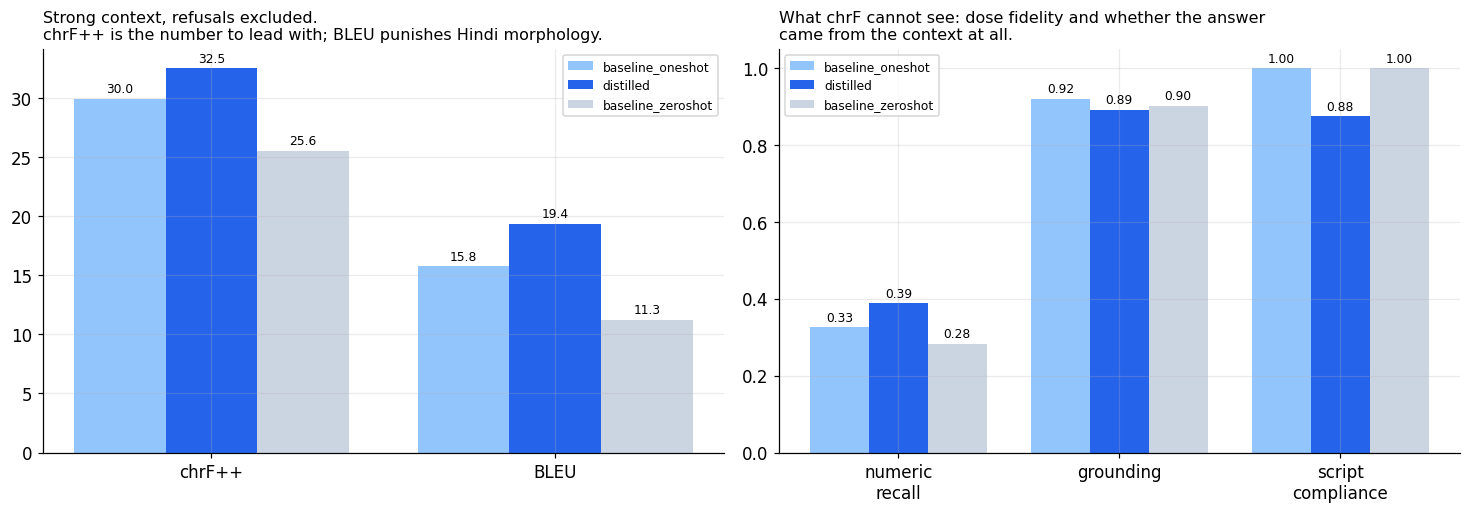

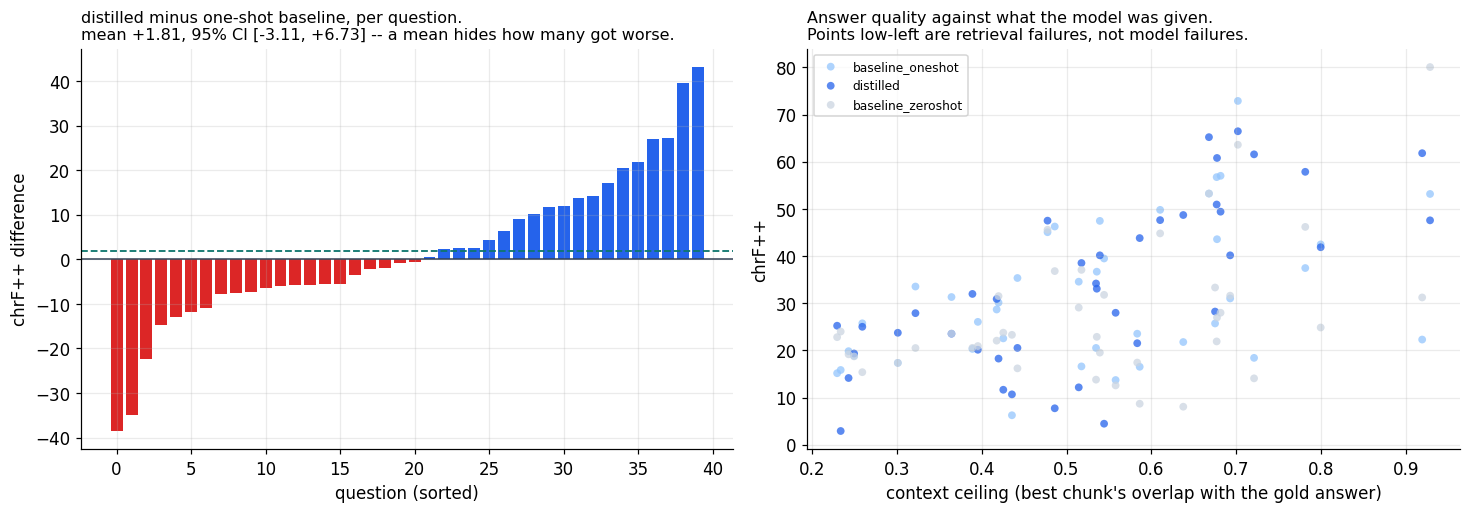

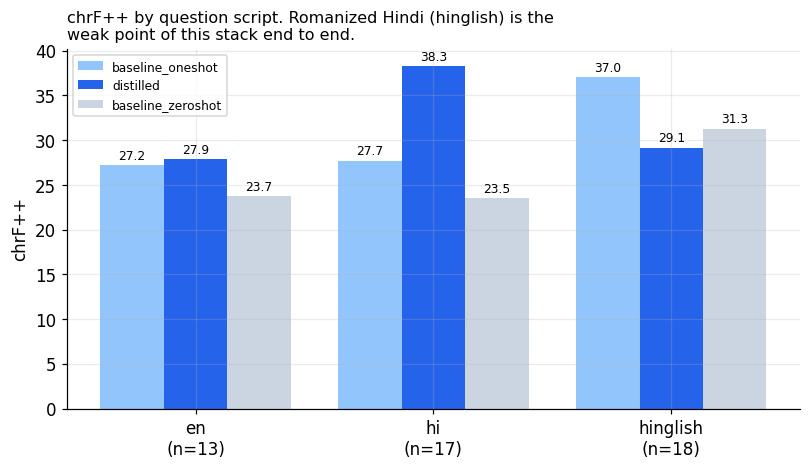

3 figures written to /kaggle/working/generation_eval/figures


In [13]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
ARM_COLORS = {"baseline_zeroshot": "#cbd5e1", "baseline_oneshot": "#93c5fd",
              "distilled": "#2563eb"}
FIGS = []

def _save(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, dpi=150, bbox_inches="tight")
    FIGS.append(p)

# ---- 1. headline metrics --------------------------------------------------------------------
try:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    ax = axes[0]
    mets = ["chrF++", "BLEU"]
    x, w = np.arange(len(mets)), 0.8 / len(ARMS)
    for j, a in enumerate(ARMS):
        v = [STRONG_T.loc[a, m] or 0 for m in mets]
        b = ax.bar(x + (j - (len(ARMS) - 1) / 2) * w, v, w, label=a, color=ARM_COLORS[a])
        ax.bar_label(b, fmt="%.1f", fontsize=8, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(mets); ax.legend(fontsize=8)
    ax.set_title("Strong context, refusals excluded.\nchrF++ is the number to lead with; "
                 "BLEU punishes Hindi morphology.", loc="left", fontsize=10.5)

    ax = axes[1]
    mets2 = ["numeric_recall", "grounding", "script_ok"]
    x = np.arange(len(mets2))
    for j, a in enumerate(ARMS):
        v = [STRONG_T.loc[a, m] if STRONG_T.loc[a, m] is not None else 0 for m in mets2]
        b = ax.bar(x + (j - (len(ARMS) - 1) / 2) * w, v, w, label=a, color=ARM_COLORS[a])
        ax.bar_label(b, fmt="%.2f", fontsize=8, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(["numeric\nrecall", "grounding", "script\ncompliance"])
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    ax.set_title("What chrF cannot see: dose fidelity and whether the answer\n"
                 "came from the context at all.", loc="left", fontsize=10.5)
    fig.tight_layout(); _save(fig, "01_headline.png"); plt.show()
except Exception as e:
    print(f"[skip] headline chart: {type(e).__name__}: {e}")

# ---- 2. paired per-question + context ceiling -----------------------------------------------
try:
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
    ax = axes[0]
    piv = _strong.pivot_table(index="qid", columns="arm", values="chrf")
    if {"baseline_oneshot", "distilled"}.issubset(piv.columns):
        d = (piv["distilled"] - piv["baseline_oneshot"]).dropna().sort_values()
        ax.bar(range(len(d)), d, color=["#dc2626" if v < 0 else "#2563eb" for v in d])
        ax.axhline(0, c="#334155", lw=1)
        mean, lo, hi = bootstrap_ci(d.tolist())
        ax.axhline(mean, c="#0f766e", ls="--", lw=1.2)
        ax.set_xlabel("question (sorted)"); ax.set_ylabel("chrF++ difference")
        ax.set_title(f"distilled minus one-shot baseline, per question.\n"
                     f"mean {mean:+.2f}, 95% CI [{lo:+.2f}, {hi:+.2f}] "
                     f"-- a mean hides how many got worse.", loc="left", fontsize=10.5)

    ax = axes[1]
    for a in ARMS:
        s = _strong[_strong["arm"] == a]
        ax.scatter(s["ctx_gold_overlap"], s["chrf"], s=26, alpha=0.75,
                   label=a, color=ARM_COLORS[a], edgecolors="none")
    ax.set_xlabel("context ceiling (best chunk's overlap with the gold answer)")
    ax.set_ylabel("chrF++")
    ax.legend(fontsize=8)
    ax.set_title("Answer quality against what the model was given.\n"
                 "Points low-left are retrieval failures, not model failures.",
                 loc="left", fontsize=10.5)
    fig.tight_layout(); _save(fig, "02_paired.png"); plt.show()
except Exception as e:
    print(f"[skip] paired chart: {type(e).__name__}: {e}")

# ---- 3. by script ----------------------------------------------------------------------------
try:
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    scripts = sorted(SCORE_DF["query_script"].unique())
    x, w = np.arange(len(scripts)), 0.8 / len(ARMS)
    for j, a in enumerate(ARMS):
        v = [BY_SCRIPT[(BY_SCRIPT["query_script"] == s) & (BY_SCRIPT["arm"] == a)]["chrF++"].iloc[0]
             if len(BY_SCRIPT[(BY_SCRIPT["query_script"] == s) & (BY_SCRIPT["arm"] == a)]) else 0
             for s in scripts]
        b = ax.bar(x + (j - (len(ARMS) - 1) / 2) * w, v, w, label=a, color=ARM_COLORS[a])
        ax.bar_label(b, fmt="%.1f", fontsize=8, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s}\n(n={int((SCORE_DF['query_script']==s).sum()/len(ARMS))})"
                        for s in scripts])
    ax.set_ylabel("chrF++"); ax.legend(fontsize=8)
    ax.set_title("chrF++ by question script. Romanized Hindi (hinglish) is the\n"
                 "weak point of this stack end to end.", loc="left", fontsize=10.5)
    fig.tight_layout(); _save(fig, "03_by_script.png"); plt.show()
except Exception as e:
    print(f"[skip] script chart: {type(e).__name__}: {e}")

print(f"{len(FIGS)} figures written to {FIG_DIR}")


## 14. Save

In [14]:
SCORE_DF.to_csv(os.path.join(OUTPUT_DIR, "generation_per_answer.csv"),
                index=False, encoding="utf-8-sig")
CTX_DF.to_csv(os.path.join(OUTPUT_DIR, "context_quality.csv"), index=False)
ALL_T.to_csv(os.path.join(OUTPUT_DIR, "summary_all.csv"))
ATT_T.to_csv(os.path.join(OUTPUT_DIR, "summary_no_refusals.csv"))
STRONG_T.to_csv(os.path.join(OUTPUT_DIR, "summary_strong_context.csv"))
BY_SCRIPT.to_csv(os.path.join(OUTPUT_DIR, "by_script.csv"), index=False)
if not DELTA_DF.empty:
    DELTA_DF.to_csv(os.path.join(OUTPUT_DIR, "head_to_head.csv"), index=False)

run_manifest = {
    "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "notebook": "12_generation_distilled_vs_oneshot",
    "scope": "GENERATION ONLY. Retrieval supplies context and is not scored anywhere here.",
    "arms": {a: ARM_CONFIG[a] for a in ARMS},
    "one_shot_exemplar": {"crop": "maize / stem borer", "hand_written": True,
                          "drawn_from_eval_set": False},
    "context": {
        "mode": CONTEXT_MODE, "top_k": CTX_TOP_K, "char_cap": CHAR_CAP,
        "retriever": "rrf(dense bge-m3 + bm25)" if USE_BM25 else "dense bge-m3",
        "identical_across_arms": True,
        "mean_ctx_gold_overlap": float(CTX_DF["ctx_gold_overlap"].mean()),
        "n_weak_context": int((CTX_DF["ctx_gold_overlap"] < 0.20).sum()),
    },
    "decoding": {"temperature": TEMPERATURE, "max_new_tokens": MAX_NEW_TOKENS,
                 "greedy": TEMPERATURE == 0},
    "models": {"baseline": BASELINE_MODEL_ID, "distilled_base": DISTILLED_BASE_MODEL_ID,
               "adapter_dir": ADAPTER_DIR, "training_manifest": TRAIN_MANIFEST},
    "n_questions": int(SCORE_DF["qid"].nunique()),
    "summary_all": json.loads(ALL_T.to_json(orient="index")),
    "summary_no_refusals": json.loads(ATT_T.to_json(orient="index")),
    "summary_strong_context": json.loads(STRONG_T.to_json(orient="index")),
    "head_to_head": json.loads(DELTA_DF.to_json(orient="records")) if not DELTA_DF.empty else [],
    "caveats": {
        "contamination": "The adapter may have trained on some of these questions. Nothing here "
                         "rules that out -- cross-check train.jsonl against the qid column in "
                         "generation_per_answer.csv before quoting any gap. Until then the "
                         "distilled numbers are an upper bound.",
        "sample_size": "n=48 paired. Any difference whose bootstrap CI crosses zero is a tie.",
        "references": "Gold answers are hand-written KCC-style notes, not corpus text. BLEU and "
                      "chrF measure agreement with one phrasing of a correct answer.",
        "one_shot_fairness": "The exemplar hands the baseline the output format for free, which "
                             "is the point: it removes formatting from the comparison so what "
                             "remains is domain behaviour.",
    },
    "figures": [os.path.basename(p) for p in FIGS],
    "total_minutes": round(minutes_used(), 1),
}
with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2, ensure_ascii=False, default=str)

_bundle = os.path.join(OUT_ROOT, "generation_eval_bundle")
shutil.rmtree(_bundle, ignore_errors=True)
shutil.make_archive(_bundle, "zip", OUTPUT_DIR)
print(f"everything in {OUTPUT_DIR}")
print(f"bundle: {_bundle}.zip")
print(f"total runtime: {minutes_used():.0f} min")


everything in /kaggle/working/generation_eval
bundle: /kaggle/working/generation_eval_bundle.zip
total runtime: 20 min


## Reading the result

**Lead with the strong-context table.** The all-questions table mixes in cases where retrieval
handed the model nothing usable; scores there are a statement about the retriever, and this
notebook is not about the retriever.

**A difference whose CI crosses zero is a tie**, and should be written up as one. With n=48 paired
questions the chrF++ interval is wide. The per-question chart is the honest companion to any mean:
if the distilled arm wins on 20 and loses on 15, "distilled is better" is a weaker claim than the
average suggests.

**Check grounding before celebrating chrF.** If the distilled arm's chrF is well above the
baseline's while its `grounding` is at or below it, the adapter learned to reproduce KCC phrasing
from its weights rather than to use the retrieved context. That looks identical to success on
these 48 questions and fails on the 49th.

**If `INCLUDE_ZERO_SHOT` was on**, the `zeroshot → oneshot` gap is the formatting component and the
`oneshot → distilled` gap is what remains. If the first is large and the second is small, the
defensible claim is that the fine-tune mostly taught output format — still useful, considerably
cheaper to state accurately than to be caught overstating.

**The dosage table is the one with real stakes.** `numeric_recall` well below 1.0 means doses are
being dropped or changed; `halluc_numbers` above zero means numbers are appearing that were in
neither the context nor the reference. Either is a safety finding and outranks every n-gram metric
on this page.

**Contamination is unresolved.** Cross-check `train.jsonl` against the `qid` column before quoting
the gap. Until that is done, treat the distilled numbers as an upper bound.

**Then re-run with `CONTEXT_MODE = "oracle"`.** If both arms improve sharply, the ceiling on this
system is retrieval, and generator work has lower marginal value than corpus or retriever work.